Importamos los datos desde el repositorio

In [123]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
# fetch dataset 
default_of_credit_card_clients = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X = default_of_credit_card_clients.data.features 
Y = default_of_credit_card_clients.data.targets 
  
# variable information 
print(default_of_credit_card_clients.variables) 

   name     role     type      demographic                 description units  \
0    ID       ID  Integer             None                        None  None   
1    X1  Feature  Integer             None                   LIMIT_BAL  None   
2    X2  Feature  Integer              Sex                         SEX  None   
3    X3  Feature  Integer  Education Level                   EDUCATION  None   
4    X4  Feature  Integer   Marital Status                    MARRIAGE  None   
5    X5  Feature  Integer              Age                         AGE  None   
6    X6  Feature  Integer             None                       PAY_0  None   
7    X7  Feature  Integer             None                       PAY_2  None   
8    X8  Feature  Integer             None                       PAY_3  None   
9    X9  Feature  Integer             None                       PAY_4  None   
10  X10  Feature  Integer             None                       PAY_5  None   
11  X11  Feature  Integer             No

Definimos variables según los metadatos que nos proporcionan en el word y que vienen definidos en la fuente

In [124]:
target = "default payment next month"

# Crear diccionario de mapeo y renombrar X
mapeo = dict(zip(default_of_credit_card_clients.variables['name'], 
                 default_of_credit_card_clients.variables['description']))
X = X.rename(columns=mapeo)

# Renombrar el target
Y = Y.rename(columns={'Y': target})

cat_var = default_of_credit_card_clients.variables.query('demographic == demographic')['description'].tolist()
print(cat_var)

# asegurar que existan en X
cat_cols = [col for col in cat_var if col in X.columns]


['SEX', 'EDUCATION', 'MARRIAGE', 'AGE']


Empezamos con el análisis de las variables categoricas y vemos como se comporta la media de nuestra variable objetivo para cada categoría

SEX
2    18112
1    11888
Name: count, dtype: int64


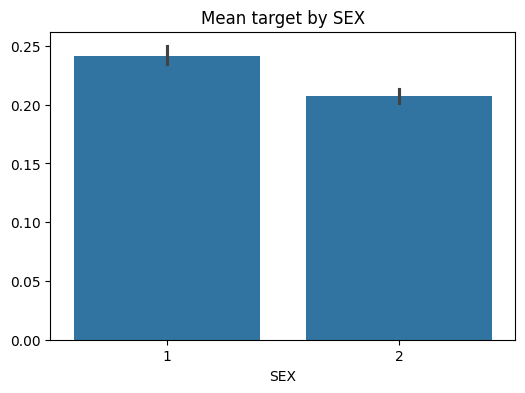

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64


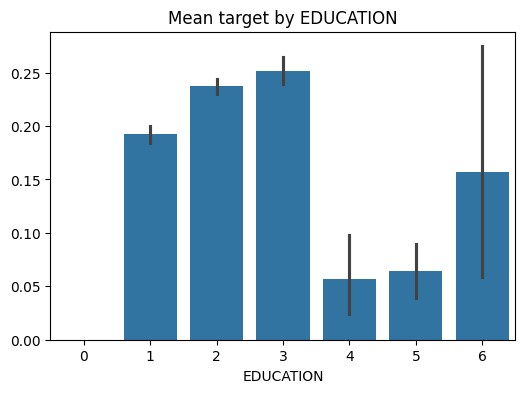

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


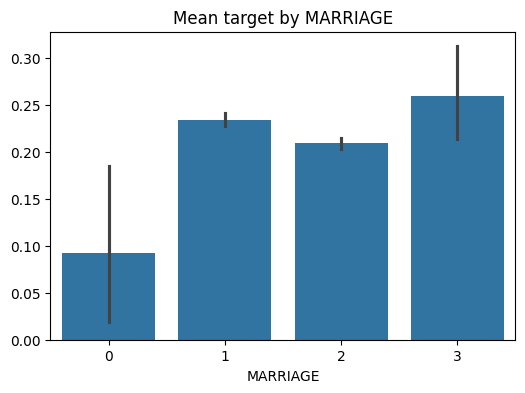

AGE
29    1605
27    1477
28    1409
30    1395
26    1256
31    1217
25    1186
34    1162
32    1158
33    1146
24    1127
35    1113
36    1108
37    1041
39     954
38     944
23     931
40     870
41     824
42     794
44     700
43     670
45     617
46     570
22     560
47     501
48     466
49     452
50     411
51     340
53     325
52     304
54     247
55     209
56     178
57     122
58     122
59      83
21      67
60      67
61      56
62      44
64      31
63      31
66      25
65      24
67      16
69      15
70      10
68       5
73       4
75       3
71       3
72       3
79       1
74       1
Name: count, dtype: int64


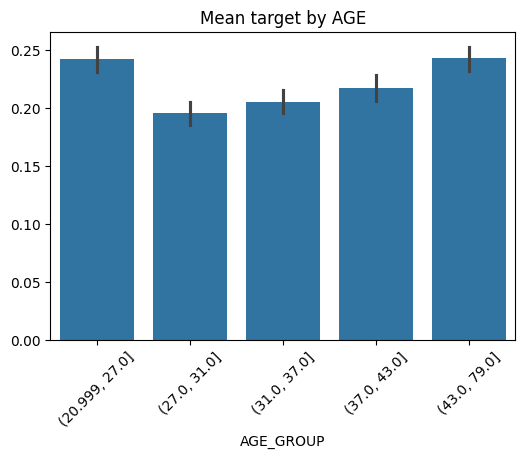

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

for var in cat_var:
    print(X[var].value_counts())
    plt.figure(figsize=(6,4))
    

    if var =="AGE":
        X['AGE_GROUP'] = pd.qcut(X['AGE'], q=5)
        sns.barplot(data=X, x='AGE_GROUP', y=Y[target].tolist())
        plt.xticks(rotation=45)
    else:
        sns.barplot(data=X, x=var, y=Y[target].tolist())
    
    plt.title(f'Mean target by {var}')
    plt.show()

X['AGE_GROUP'] = X['AGE_GROUP'].cat.codes

In [126]:
for col in cat_var:
    if col in X.columns:
        X[col] = X[col].astype("category")

# Agrupamos los datos desconocidos de educación en una misma categoría pues representan lo mismo
X["EDUCATION"] = X["EDUCATION"].replace([0, 6], 5)

pays = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]


# Como el estatus Marriage = 0 no está definido y son 54/30000 registros, vamos a compararlo con otros datos para decidir que hacer con él.

# --- FEATURES NUMÉRICAS ---
pay_cols = [f"PAY_AMT{i}" for i in range(1, 7)]
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
num_cols = pay_cols+bill_cols+ ['LIMIT_BAL']

grupos = {
    'MARRIAGE=3': X[X['MARRIAGE'] == 3],
    'Resto':      X[X['MARRIAGE'] != 0]
}


media_0 = X[X['MARRIAGE'] == 0][num_cols].mean()

for nombre, grupo in grupos.items():
    diff = (media_0 - grupo[num_cols].mean()).round(2)
    print("="*50)
    print(f"MARRIAGE=0 vs {nombre} ")
    print(diff)


MARRIAGE=0 vs MARRIAGE=3 
PAY_AMT1       884.65
PAY_AMT2     -5083.19
PAY_AMT3     -2122.14
PAY_AMT4     -2256.96
PAY_AMT5     -2439.40
PAY_AMT6     -1170.60
BILL_AMT1   -22775.40
BILL_AMT2   -16084.00
BILL_AMT3   -17959.18
BILL_AMT4   -12223.08
BILL_AMT5   -10550.05
BILL_AMT6   -11767.27
LIMIT_BAL    34882.47
dtype: float64
MARRIAGE=0 vs Resto 
PAY_AMT1      2135.37
PAY_AMT2     -3144.88
PAY_AMT3     -1199.90
PAY_AMT4     -1965.39
PAY_AMT5     -2679.69
PAY_AMT6     -2982.48
BILL_AMT1   -30878.30
BILL_AMT2   -25259.76
BILL_AMT3   -27809.84
BILL_AMT4   -24299.47
BILL_AMT5   -22632.94
BILL_AMT6   -22096.11
LIMIT_BAL   -34583.61
dtype: float64


C:\Users\AxelAarónLunaQuiñone\AppData\Local\Temp\ipykernel_25052\3685808530.py:6: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X["EDUCATION"] = X["EDUCATION"].replace([0, 6], 5)


Es una diferencia grande en la variable objetivo y son diferencias considerables con el resto de variables numericas. Esto puede provocar overfitting en una variable pequeña y al no saber de donde proviene y ser tan pocos registros considero que la mejor opción es eliminarlo del modelo.

In [127]:

X = X[X['MARRIAGE'] != 0]

Agregamos más features categoricas

In [128]:

#Agrego flags para indicar si dentro de los 6 meses hubo clientes que se atrasaron, se adelantaron o se atrasaron 2 o más meses


X["DULY_PAYS"] = (X[pays] < 0).any(axis=1)
X["DELAY_PAYS"] = (X[pays] > 0).any(axis=1)
X["DELAY_PAYS2"] = (X[pays] >= 2).any(axis=1)

Ahora analizamos variables numericas

In [129]:
(X[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
PAY_AMT1,29946.0,5659.736826,16552.642231,0.0,1000.00,2100.0,5007.00,873552.0
PAY_AMT2,29946.0,5926.824284,23060.224734,0.0,836.00,2010.0,5000.00,1684259.0
PAY_AMT3,29946.0,5227.841314,17618.433069,0.0,390.00,1800.0,4511.50,896040.0
PAY_AMT4,29946.0,4829.614573,15677.788192,0.0,298.00,1500.0,4015.00,621000.0
PAY_AMT5,29946.0,4804.211080,15290.655486,0.0,255.25,1500.0,4040.75,426529.0
PAY_AMT6,29946.0,5220.871035,17791.413753,0.0,122.00,1500.0,4000.00,528666.0
BILL_AMT1,29946.0,51278.911841,73682.871378,-165580.0,3570.25,22400.0,67263.00,964511.0
BILL_AMT2,29946.0,49224.542744,71219.298988,-69777.0,2988.25,21221.0,64108.00,983931.0
BILL_AMT3,29946.0,47063.212516,69393.213662,-157264.0,2684.50,20108.0,60240.75,1664089.0
BILL_AMT4,29946.0,43306.688005,64374.889734,-170000.0,2335.00,19066.0,54601.75,891586.0


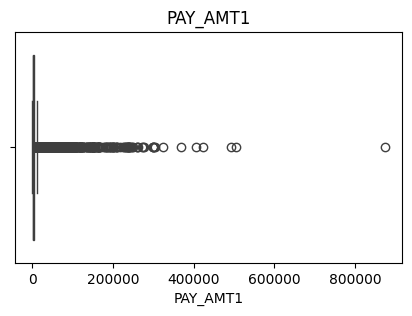

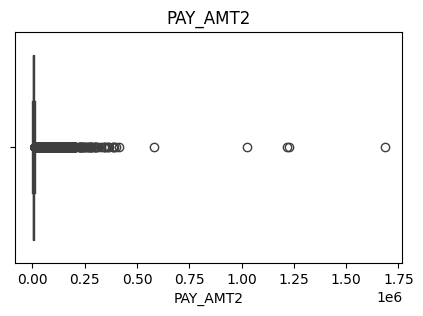

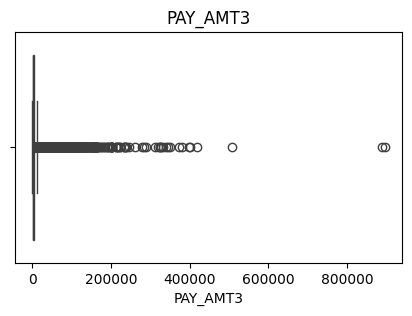

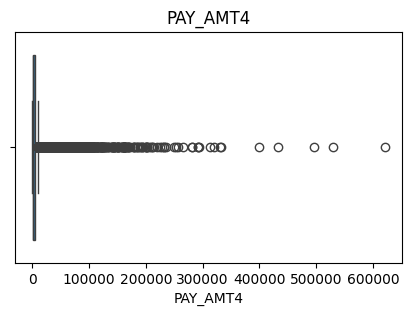

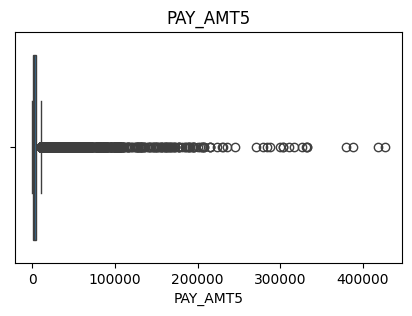

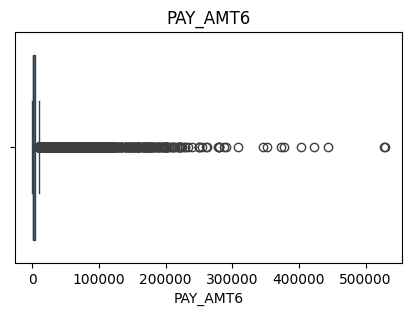

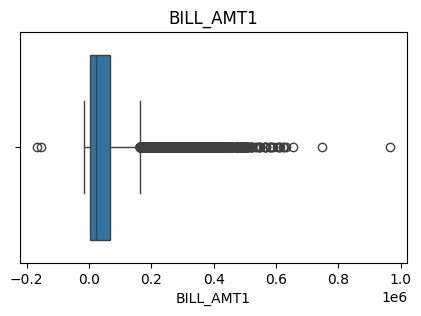

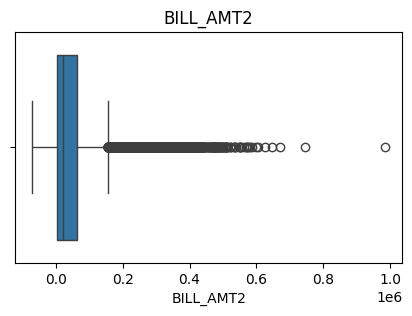

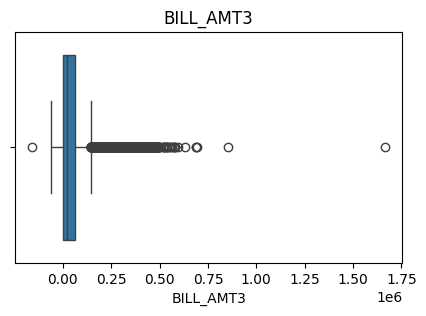

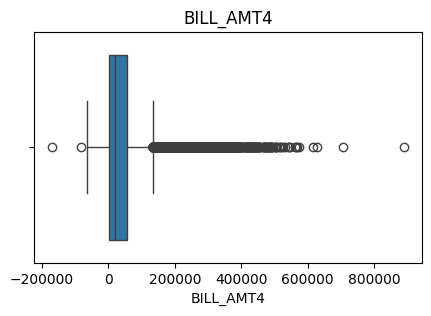

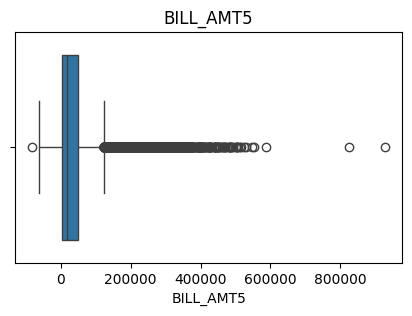

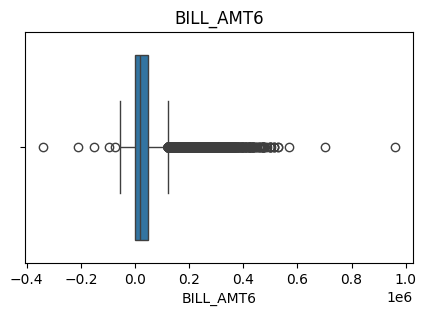

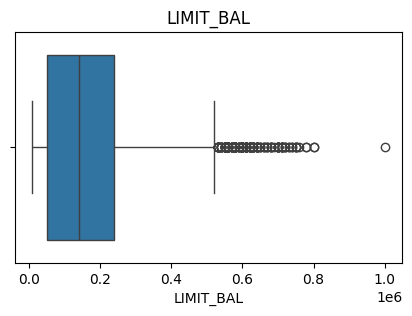

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=X[col])
    plt.title(col)
    plt.show()

Creamos variables que nos indiquen la media de los montos de deuda y pagados de los 6 meses. También pueden servir variables como la tasa de la deuda sobre el limite de crédito, la deuda neta actual de septiembre y la cantidad de meses que se atrasó en total

In [131]:
X["PAY_AMT_AVG"] = X[pay_cols].mean(axis=1)
X["BILL_AMT_AVG"] = X[bill_cols].mean(axis=1)

X['util_credito'] = X['BILL_AMT1'] / X['LIMIT_BAL']
X['deuda_neta']   = X[bill_cols].sum(axis=1) - X[pay_cols].sum(axis=1)

X['meses_delay']  = (X[pays] > 0).sum(axis=1)



Voy a imprimir una matriz de correlación para ver con que variables está más correlacionado el target e identificar circularidades en los features. Usaré correlación de Spearman dado que el dataset contiene variables ordinales (historial de pagos) y distribuciones monetarias con sesgo.

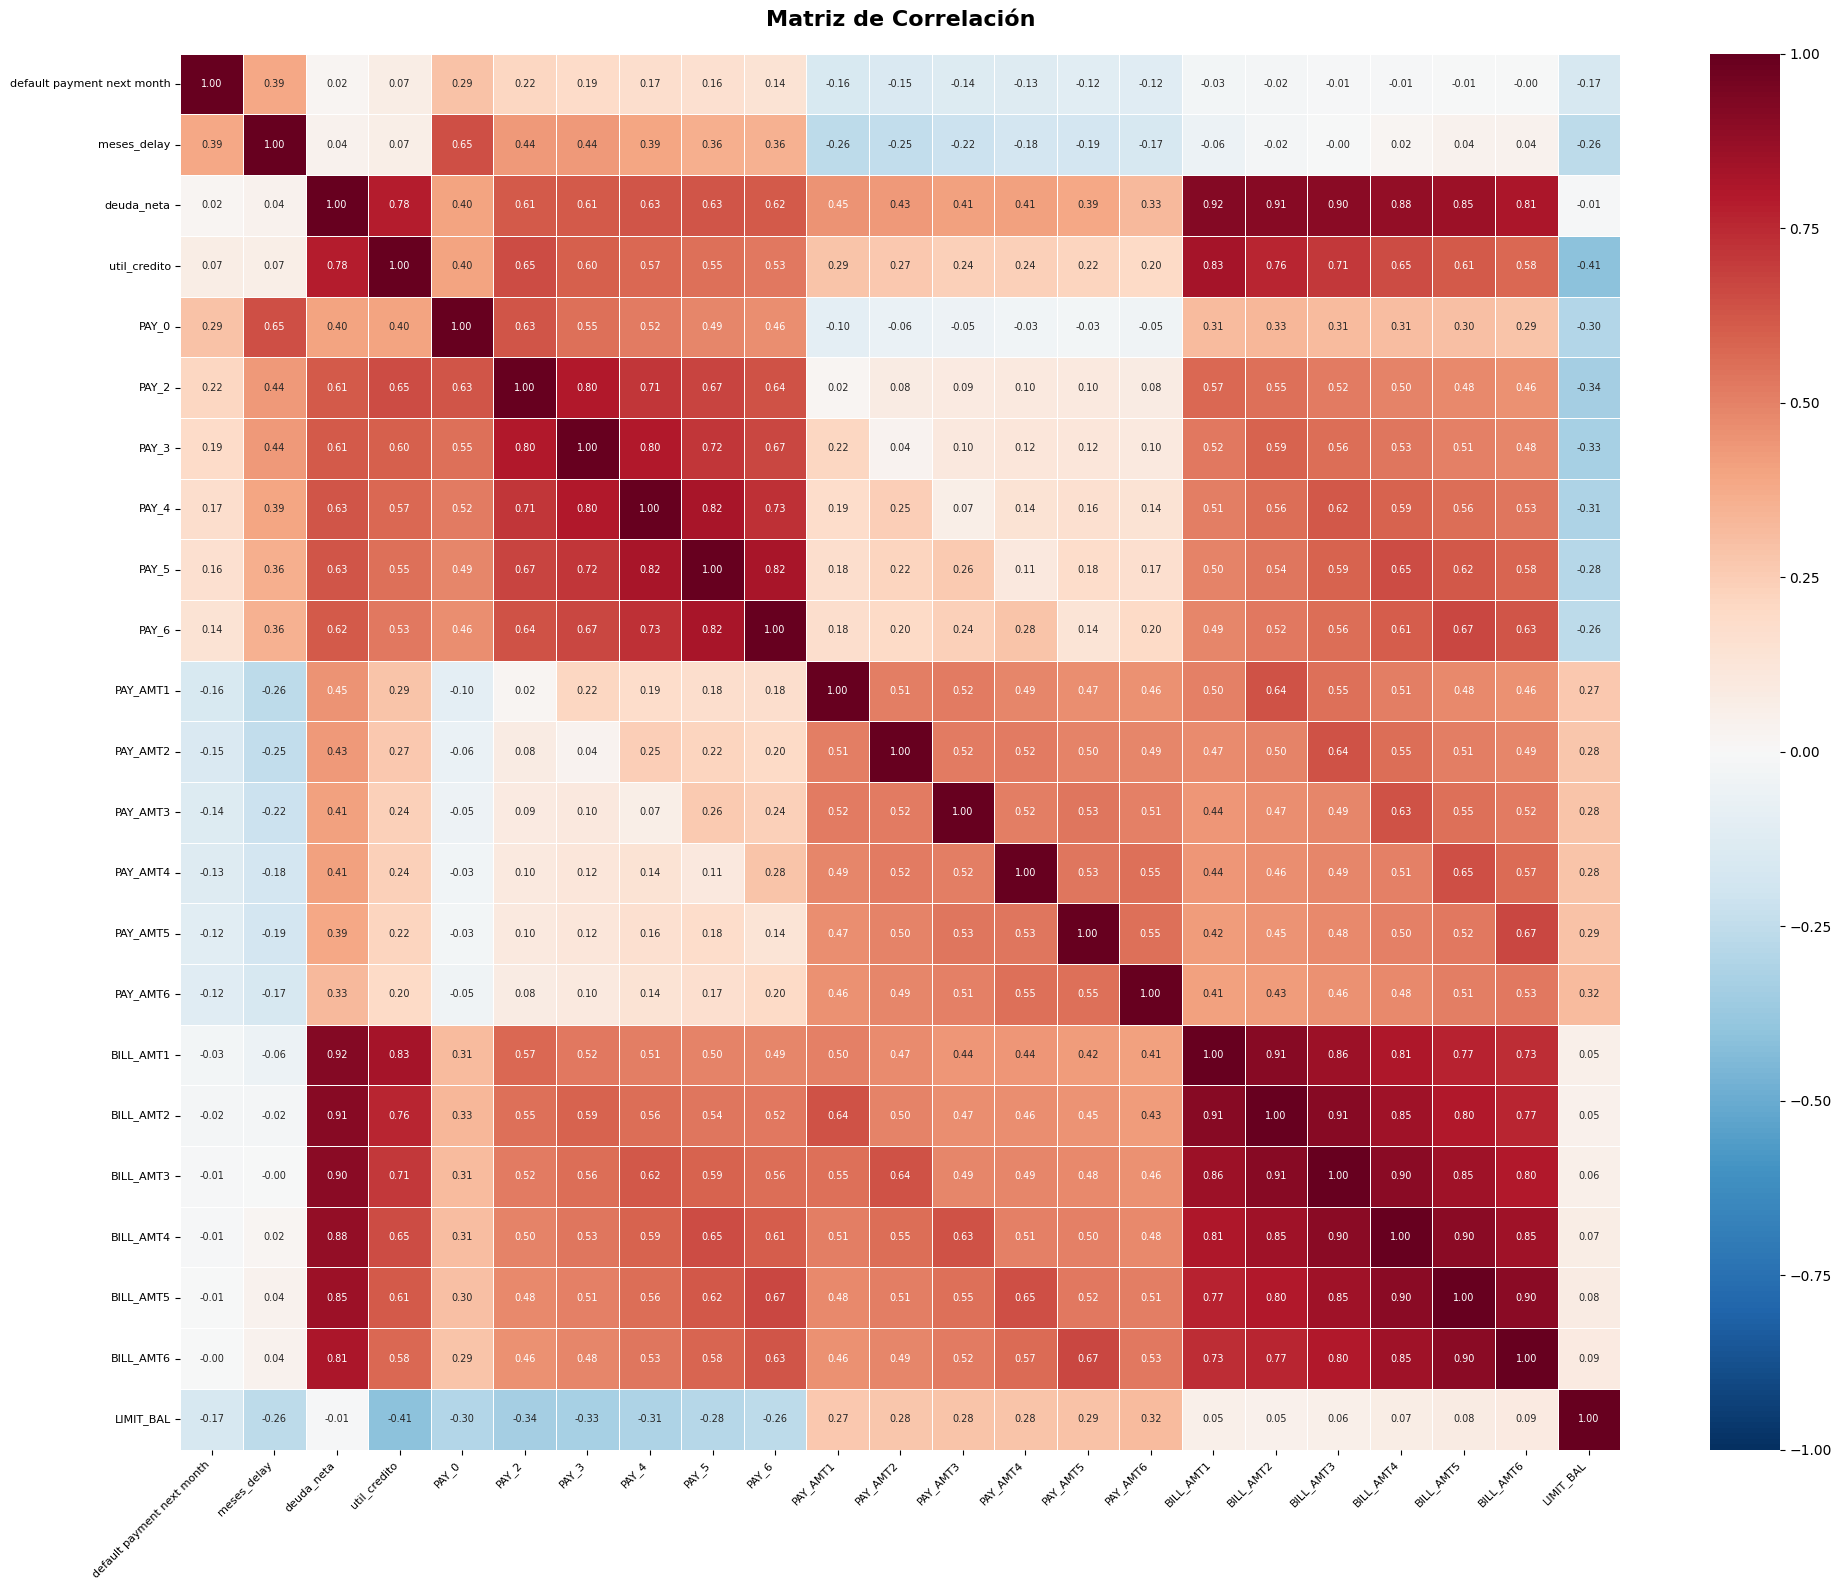

In [132]:
# Unir X e Y con target primero
# Sincronizar Y con el índice de X
Y = Y.loc[X.index]
df_corr = pd.concat([Y, X], axis=1)
df_corr = df_corr[[target,'meses_delay','deuda_neta','util_credito']+pays+num_cols]
# Calcular correlación
corr = df_corr.corr(method='spearman')

# Graficar
fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 7},
    ax=ax
)
ax.set_title("Matriz de Correlación", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Las variables con mayor asociación con el target son meses_delay (r=0.39), PAY_0 (r=0.29) y deuda_neta (r=-0.26). Se identificaron posibles redundancias entre meses_delay y PAY_2 a PAY_6, dado que la primera es un conteo directo derivado de estas, y entre util_credito y BILL_AMT1 por capturar señal similar. Para evaluar su impacto real, se compararán los resultados del modelo con y sin estas variables.


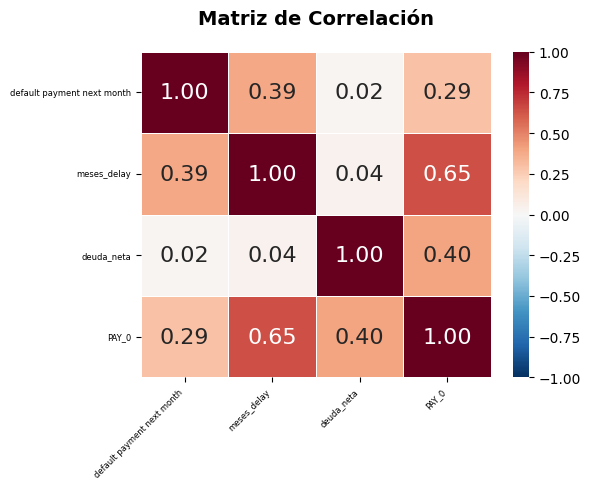

In [133]:
df_corr = df_corr[[target,'meses_delay','deuda_neta','PAY_0']]
corr = df_corr.corr(method='spearman')
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 16},  # números más grandes
    ax=ax
)
ax.set_title("Matriz de Correlación", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

COmo encontramos muchos ouliers en variables de monto vamos aplicar transformación logarítmica (log1p) a las variables monetarias (BILL_AMT, PAY_AMT, LIMIT_BAL) para reducir el sesgo generado por valores extremos y mejorar la distribución de las variables de entrada.

In [134]:
import numpy as np

log_cols = num_cols + ['LIMIT_BAL','deuda_neta','util_credito', 'BILL_AMT_AVG', 'PAY_AMT_AVG']

for col in log_cols:
    X[f"{col}_log"] = np.log1p(X[col] - X[col].min() + 1)

Ahora generamos los sets de prueba y test. Eliminamos columnas redundantes con las que ya creamos.

In [135]:
from sklearn.model_selection import train_test_split
X_log = X.drop(columns=log_cols+["AGE"], errors='ignore')
print(X_log.columns)
# Split train/test: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_log, Y, test_size=0.20, random_state=42, stratify=Y
)

# Split de validación: 80% train, 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, stratify=y_train
)

print(f"Train: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val:   {X_val.shape[0]:,} registros ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.1f}%)")

Index(['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4',
       'PAY_5', 'PAY_6', 'AGE_GROUP', 'DULY_PAYS', 'DELAY_PAYS', 'DELAY_PAYS2',
       'meses_delay', 'PAY_AMT1_log', 'PAY_AMT2_log', 'PAY_AMT3_log',
       'PAY_AMT4_log', 'PAY_AMT5_log', 'PAY_AMT6_log', 'BILL_AMT1_log',
       'BILL_AMT2_log', 'BILL_AMT3_log', 'BILL_AMT4_log', 'BILL_AMT5_log',
       'BILL_AMT6_log', 'LIMIT_BAL_log', 'deuda_neta_log', 'util_credito_log',
       'BILL_AMT_AVG_log', 'PAY_AMT_AVG_log'],
      dtype='object')
Train: 19,164 registros (64.0%)
Val:   4,792 registros (16.0%)
Test:  5,990 registros (20.0%)


Vamos a comparar algunos modelos para elegir un baseline

In [136]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
y_train = y_train.squeeze()
modelos = {
    'GBT':           GradientBoostingClassifier(random_state=42),
    'XGBoost':       XGBClassifier(random_state=42, eval_metric='logloss', 
                                   verbosity=0, enable_categorical=True),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 50)
print("        BASELINE — CROSS VALIDATION (k=5)")
print("=" * 50)

resultados = {}
for nombre, modelo in modelos.items():
    aucs = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='roc_auc')
    resultados[nombre] = aucs
    print(f"{nombre:20s} AUC: {aucs.mean():.4f} (± {aucs.std():.4f})")

print("=" * 50)

        BASELINE — CROSS VALIDATION (k=5)
GBT                  AUC: 0.7873 (± 0.0045)
XGBoost              AUC: 0.7651 (± 0.0074)
Decision Tree        AUC: 0.6066 (± 0.0047)


Ahora voy a ver el feature importance del modelo más alto

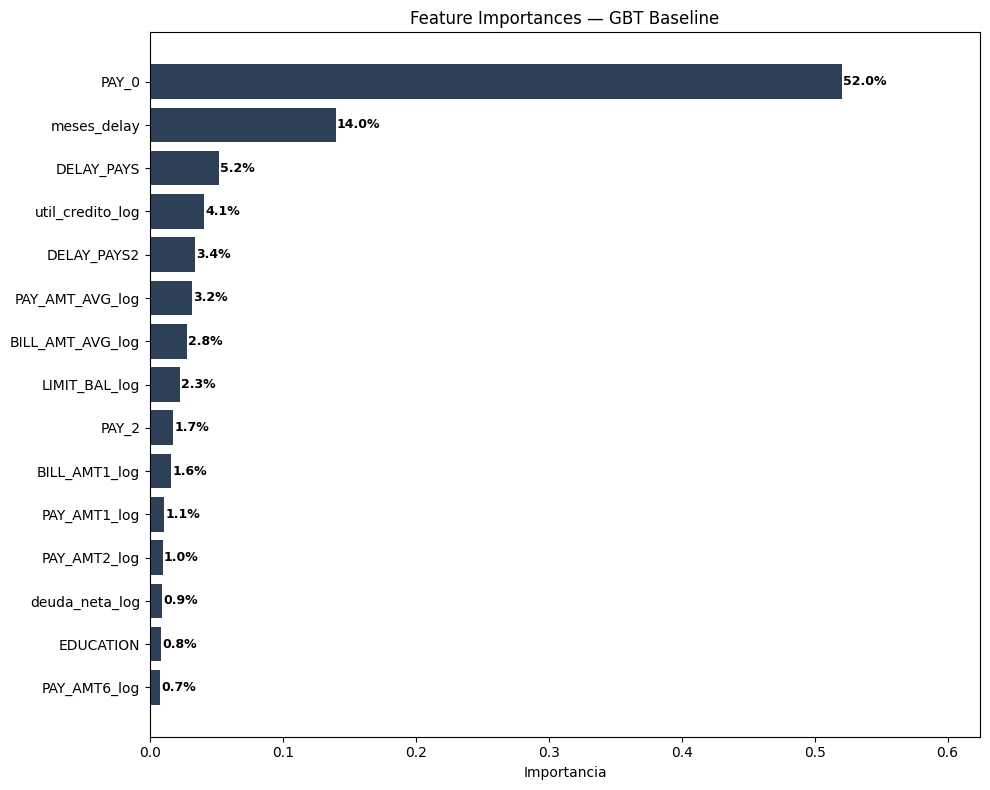

In [137]:
gbt_baseline = GradientBoostingClassifier(random_state=42)
gbt_baseline.fit(X_train, y_train)

importances = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': gbt_baseline.feature_importances_
}).sort_values('importance', ascending=False)

# Gráfica
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importances['feature'][:15], importances['importance'][:15], color='#2E4057')

for bar, val in zip(bars, importances['importance'][:15]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Importancia')
ax.set_title('Feature Importances — GBT Baseline')
ax.set_xlim(0, importances['importance'][:15].max() * 1.2)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Tres de las variables que agregamos parecen ser redundantes por lo que vamos a eliminarlas porque podrían estar produciendo circularidad

In [138]:
drop_cols = ['DELAY_PAYS2', 'BILL_AMT_AVG_log', 'PAY_AMT_AVG_log']

X_train = X_train.drop(columns=drop_cols)
X_val   = X_val.drop(columns=drop_cols)
X_test  = X_test.drop(columns=drop_cols)

Ahora sí procedemos con el modelo

In [ ]:
import itertools
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             precision_recall_curve, f1_score, fbeta_score)

# Metricas
def best_threshold_f1(y_true, y_proba):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return thresholds[np.argmax(f1[:-1])]

def best_threshold_f2(y_true, y_proba):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f2 = 5 * precision * recall / (4 * precision + recall + 1e-9)
    return thresholds[np.argmax(f2[:-1])]

def best_threshold_cost(y_true, y_proba):
    thresholds = np.arange(0.1, 0.7, 0.01)
    best_score, best_t = -np.inf, 0.5
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        score = (tp * 1 + fp * -0.3 + tn * 0 + fn * -1) / len(y_true)
        if score > best_score:
            best_score, best_t = score, t
    return best_t

def compute_lift_20(y_true, y_proba):
    df_l = pd.DataFrame({'y': np.array(y_true), 'p': y_proba})
    df_l = df_l.sort_values('p', ascending=False)
    top  = df_l.head(int(len(df_l) * 0.20))
    return top['y'].mean() / np.array(y_true).mean()

def evaluate(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'auc':       roc_auc_score(y_true, y_proba),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'f2':        fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'cost':      (tp * 1 + fp * -0.3 + tn * 0 + fn * -1) / len(y_true),
        'recall':    tp / (tp + fn) if (tp + fn) > 0 else 0,
        'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'lift_20':   compute_lift_20(y_true, y_proba),
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn
    }


y_train_arr = y_train.values.ravel()
y_val_arr   = y_val.values.ravel()

# Grid
param_grid = {
    'n_estimators':  [190],
    'learning_rate': [0.03, 0.05],
    'max_depth':     [4],
    'loss':          ['log_loss', 'exponential']
}

cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
combinations = list(itertools.product(*param_grid.values()))
keys         = list(param_grid.keys())

# ── ESTIMACIÓN DE TIEMPO ──────────────────────────────────
params_test = dict(zip(keys, combinations[0]))
t0_est = time.time()
for train_idx, val_idx in cv.split(X_train, y_train_arr):
    GradientBoostingClassifier(**params_test, random_state=42).fit(
        X_train.iloc[train_idx], y_train_arr[train_idx])
tiempo_1 = time.time() - t0_est

total_estimado = tiempo_1 * len(combinations)
print(f"Tiempo por combinación: {tiempo_1:.1f}s")
print(f"Total estimado:         {total_estimado/60:.1f} min")
print(f"Total combinaciones:    {len(combinations)}")
print("=" * 90)

# optimizacion de hiperparametros
resultados = []
t0_loop = time.time()

for i, combo in enumerate(combinations):
    params = dict(zip(keys, combo))
    fold_aucs, fold_probas, fold_trues = [], [], []

    for train_idx, val_idx in cv.split(X_train, y_train_arr):
        Xf_tr  = X_train.iloc[train_idx]
        Xf_val = X_train.iloc[val_idx]
        yf_tr  = y_train_arr[train_idx]
        yf_val = y_train_arr[val_idx]

        modelo = GradientBoostingClassifier(**params, random_state=42)
        modelo.fit(Xf_tr, yf_tr)
        proba  = modelo.predict_proba(Xf_val)[:, 1]

        fold_aucs.append(roc_auc_score(yf_val, proba))
        fold_probas.extend(proba)
        fold_trues.extend(yf_val)

    y_all    = np.array(fold_trues)
    p_all    = np.array(fold_probas)
    mean_auc = np.mean(fold_aucs)
    std_auc  = np.std(fold_aucs)

    t_f1   = best_threshold_f1(y_all, p_all)
    t_f2   = best_threshold_f2(y_all, p_all)
    t_cost = best_threshold_cost(y_all, p_all)

    resultados.append({
        **params,
        'auc_mean': mean_auc, 'auc_std': std_auc,
        'threshold_f1': t_f1, 'threshold_f2': t_f2, 'threshold_cost': t_cost
    })

    elapsed  = time.time() - t0_loop
    restante = (elapsed / (i + 1)) * (len(combinations) - i - 1)
    print(f"[{i+1:3d}/{len(combinations)}] n={params['n_estimators']:3d} "
          f"lr={params['learning_rate']:.2f} depth={params['max_depth']} "
          f"loss={params['loss']:11s} | AUC={mean_auc:.4f}(±{std_auc:.4f}) | "
          f"t_f1={t_f1:.2f} t_f2={t_f2:.2f} t_cost={t_cost:.2f} | "
          f"ETA:{restante/60:.1f}min")


Tiempo por combinación: 73.0s
Total estimado:         4.9 min
Total combinaciones:    4
[  1/4] n=190 lr=0.03 depth=4 loss=log_loss    | AUC=0.7865(±0.0050) | t_f1=0.26 t_f2=0.12 t_cost=0.14 | ETA:3.6min
[  2/4] n=190 lr=0.03 depth=4 loss=exponential | AUC=0.7868(±0.0043) | t_f1=0.26 t_f2=0.13 t_cost=0.13 | ETA:2.4min
[  3/4] n=190 lr=0.05 depth=4 loss=log_loss    | AUC=0.7861(±0.0045) | t_f1=0.26 t_f2=0.12 t_cost=0.12 | ETA:1.4min
[  4/4] n=190 lr=0.05 depth=4 loss=exponential | AUC=0.7866(±0.0038) | t_f1=0.26 t_f2=0.12 t_cost=0.12 | ETA:0.0min


In [ ]:

# Resultados
df_res = pd.DataFrame(resultados).sort_values('auc_mean', ascending=False)

print("\n" + "=" * 90)
print("TOP 5 MODELOS POR AUC")
print("=" * 90)
print(df_res.head(5)[['n_estimators','learning_rate','max_depth','loss',
                       'auc_mean','auc_std','threshold_f1',
                       'threshold_f2','threshold_cost']].to_string(index=False))


TOP 5 MODELOS POR AUC
 n_estimators  learning_rate  max_depth        loss  auc_mean  auc_std  threshold_f1  threshold_f2  threshold_cost
          190           0.03          4 exponential  0.786810 0.004334      0.263231      0.126602            0.13
          190           0.05          4 exponential  0.786635 0.003821      0.259678      0.121700            0.12
          190           0.03          4    log_loss  0.786503 0.004967      0.258825      0.119361            0.14
          190           0.05          4    log_loss  0.786059 0.004475      0.263660      0.117635            0.12


In [ ]:
# Mejor modelo
best        = df_res.iloc[0]
best_params = {k: best[k] for k in keys}

print(f"\nMejores parámetros: {best_params}")

modelo_final = GradientBoostingClassifier(**best_params, random_state=42)
modelo_final.fit(X_train, y_train_arr)
proba_val = modelo_final.predict_proba(X_val)[:, 1]

print("\n" + "=" * 90)
print("EVALUACIÓN EN VALIDATION SET — MEJOR MODELO")
print("=" * 90)
for metric, t in [('F1',   best['threshold_f1']),
                  ('F2',   best['threshold_f2']),
                  ('Cost', best['threshold_cost'])]:
    m = evaluate(y_val_arr, proba_val, t)
    print(f"\n── Umbral optimizado por {metric} (t={t:.2f}) ──")
    print(f"  AUC:{m['auc']:.4f} | Recall:{m['recall']:.4f} | "
          f"Precision:{m['precision']:.4f} | F1:{m['f1']:.4f} | "
          f"F2:{m['f2']:.4f} | Cost:{m['cost']:.4f} | Lift@20%:{m['lift_20']:.2f}x")
    print(f"  TP:{m['tp']:4d} FP:{m['fp']:4d} TN:{m['tn']:4d} FN:{m['fn']:4d}")


Mejores parámetros: {'n_estimators': np.int64(190), 'learning_rate': np.float64(0.03), 'max_depth': np.int64(4), 'loss': 'exponential'}

EVALUACIÓN EN VALIDATION SET — MEJOR MODELO

── Umbral optimizado por F1 (t=0.26) ──
  AUC:0.7869 | Recall:0.5806 | Precision:0.5265 | F1:0.5522 | F2:0.5689 | Cost:0.0010 | Lift@20%:2.66x
  TP: 616 FP: 554 TN:3177 FN: 445

── Umbral optimizado por F2 (t=0.13) ──
  AUC:0.7869 | Recall:0.8388 | Precision:0.3229 | F1:0.4663 | F2:0.6357 | Cost:0.0332 | Lift@20%:2.66x
  TP: 890 FP:1866 TN:1865 FN: 171

── Umbral optimizado por Cost (t=0.13) ──
  AUC:0.7869 | Recall:0.8294 | Precision:0.3284 | F1:0.4705 | F2:0.6355 | Cost:0.0332 | Lift@20%:2.66x
  TP: 880 FP:1800 TN:1931 FN: 181


In [ ]:
# Evaluación final
proba_test = modelo_final.predict_proba(X_test)[:, 1]
y_test_arr = y_test.values.ravel()

print("=" * 70)
print("      EVALUACIÓN FINAL — TEST SET")
print("=" * 70)

for metric, t in [('F1',   best['threshold_f1']),
                  ('F2',   best['threshold_f2']),
                  ('Cost', best['threshold_cost'])]:
    m = evaluate(y_test_arr, proba_test, t)
    print(f"\n── Umbral optimizado por {metric} (t={t:.2f}) ──")
    print(f"  AUC:       {m['auc']:.4f}")
    print(f"  Recall:    {m['recall']:.4f}  ({m['recall']*100:.1f}%)")
    print(f"  Precision: {m['precision']:.4f}  ({m['precision']*100:.1f}%)")
    print(f"  F1:        {m['f1']:.4f}")
    print(f"  F2:        {m['f2']:.4f}")
    print(f"  Cost:      {m['cost']:.4f}")
    print(f"  Lift@20%:  {m['lift_20']:.2f}x")
    print(f"  TP:{m['tp']:4d}  FP:{m['fp']:4d}  TN:{m['tn']:4d}  FN:{m['fn']:4d}")
    print(f"  Ganancia total: {m['cost']*len(y_test_arr):.2f}")

print("\n" + "=" * 70)
print(f"Registros en test set: {len(y_test_arr):,}")
print(f"Default rate real:     {y_test_arr.mean():.3f} ({y_test_arr.mean()*100:.1f}%)")
print("=" * 70)

      EVALUACIÓN FINAL — TEST SET

── Umbral optimizado por F1 (t=0.26) ──
  AUC:       0.7740
  Recall:    0.5558  (55.6%)
  Precision: 0.5147  (51.5%)
  F1:        0.5344
  F2:        0.5471
  Cost:      -0.0101
  Lift@20%:  2.51x
  TP: 737  FP: 695  TN:3969  FN: 589
  Ganancia total: -60.50

── Umbral optimizado por F2 (t=0.13) ──
  AUC:       0.7740
  Recall:    0.8416  (84.2%)
  Precision: 0.3209  (32.1%)
  F1:        0.4646
  F2:        0.6354
  Cost:      0.0330
  Lift@20%:  2.51x
  TP:1116  FP:2362  TN:2302  FN: 210
  Ganancia total: 197.40

── Umbral optimizado por Cost (t=0.13) ──
  AUC:       0.7740
  Recall:    0.8371  (83.7%)
  Precision: 0.3272  (32.7%)
  F1:        0.4705
  F2:        0.6382
  Cost:      0.0350
  Lift@20%:  2.51x
  TP:1110  FP:2282  TN:2382  FN: 216
  Ganancia total: 209.40

Registros en test set: 5,990
Default rate real:     0.221 (22.1%)


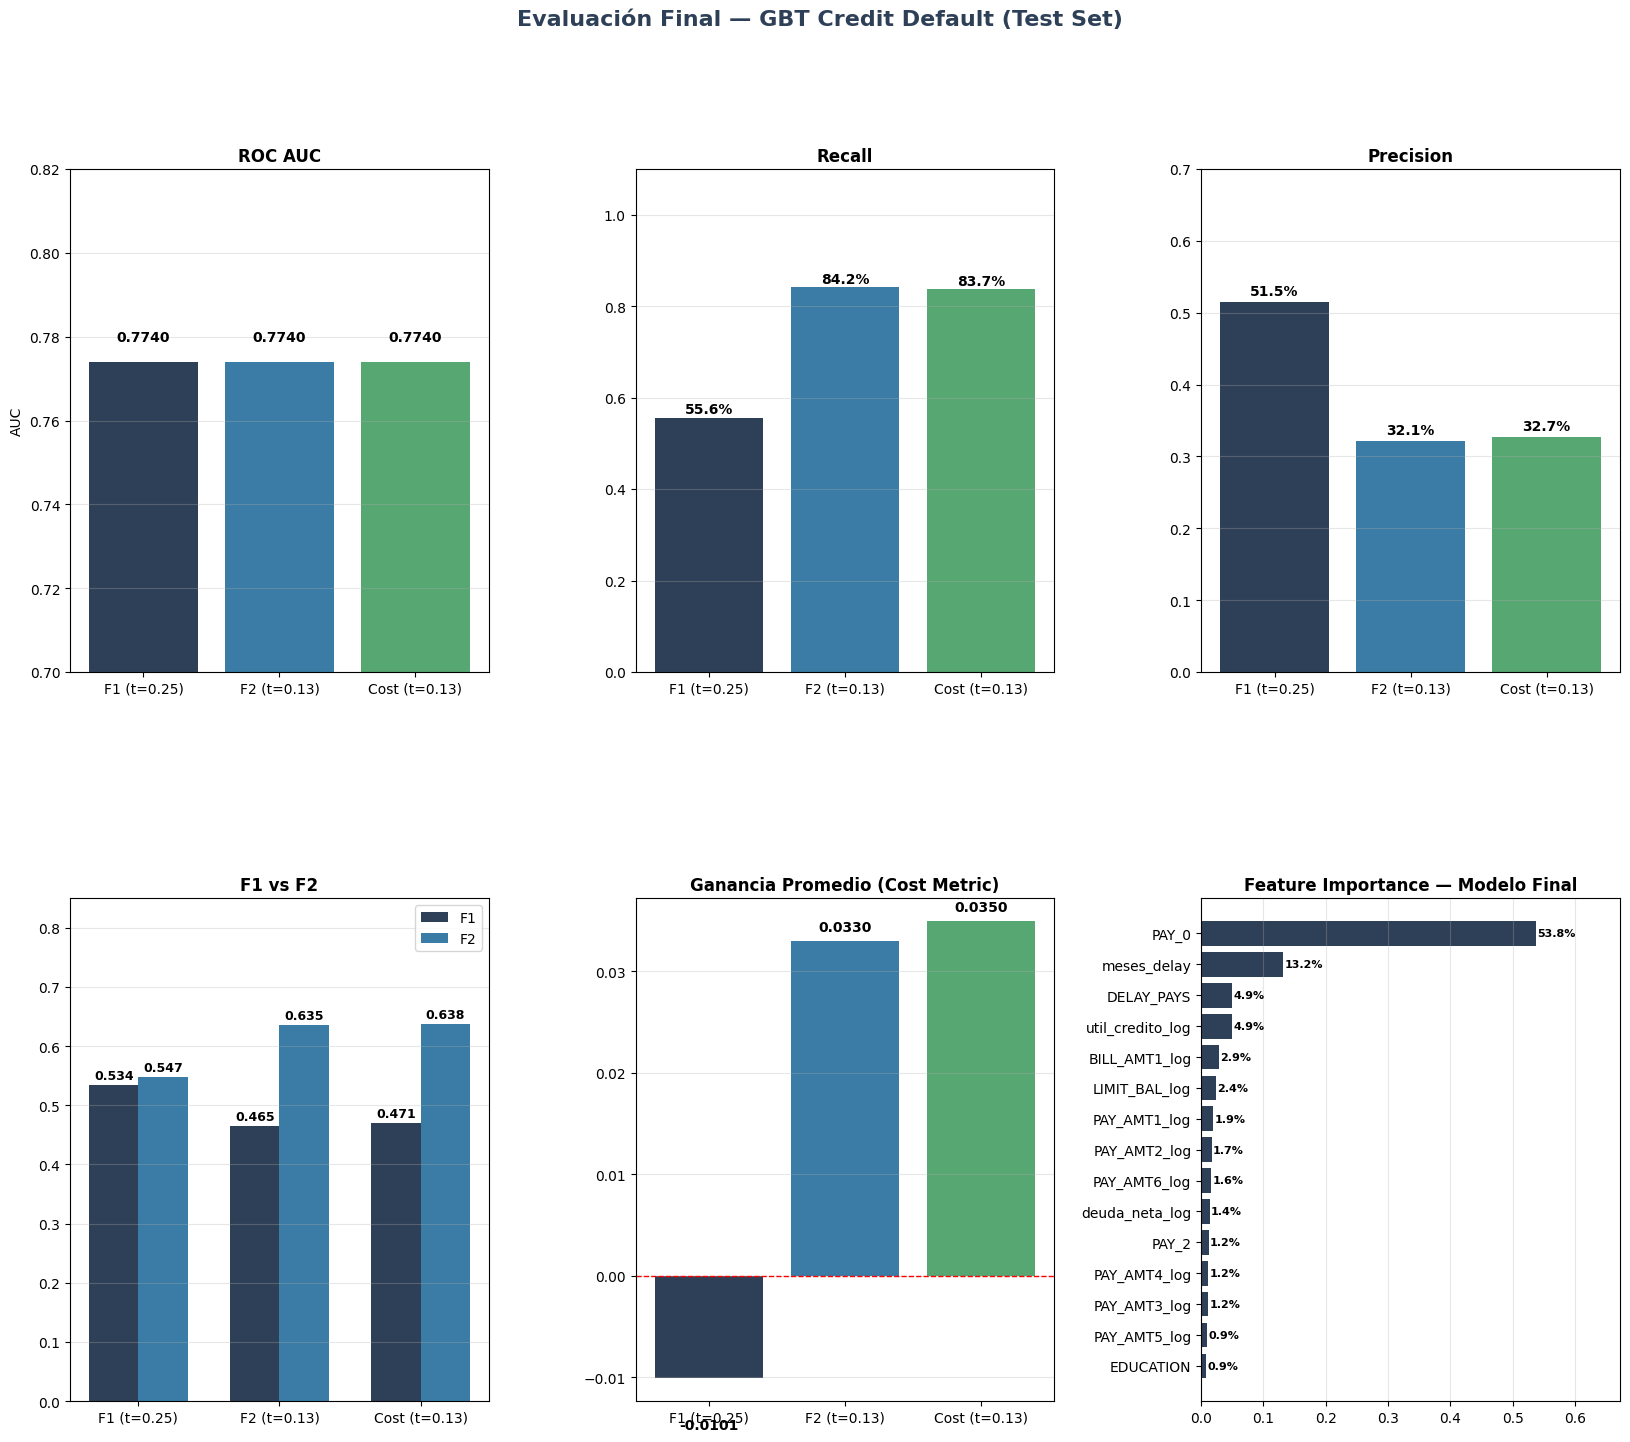

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── FEATURE IMPORTANCE ────────────────────────────────────
importances = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': modelo_final.feature_importances_
}).sort_values('importance', ascending=False)


umbrales = {
    'F1 (t=0.25)':   best['threshold_f1'],
    'F2 (t=0.13)':   best['threshold_f2'],
    'Cost (t=0.13)': best['threshold_cost']
}

metricas_plot = {}
for nombre, t in umbrales.items():
    m = evaluate(y_test_arr, proba_test, t)
    metricas_plot[nombre] = m

# ── FIGURA ────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

colores_umbrales = ['#2E4057', '#3A7CA5', '#57A773']
colores_metrics  = ['#2E4057', '#3A7CA5', '#57A773', '#E63946', '#F4A261']

# AUC por umbral
ax1 = fig.add_subplot(gs[0, 0])
vals = [metricas_plot[u]['auc'] for u in umbrales]
bars = ax1.bar(umbrales.keys(), vals, color=colores_umbrales)
for bar, v in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)
ax1.set_ylim(0.7, 0.82)
ax1.set_title('ROC AUC', fontweight='bold')
ax1.set_ylabel('AUC')
ax1.grid(alpha=0.3, axis='y')

# Recall por umbral
ax2 = fig.add_subplot(gs[0, 1])
vals = [metricas_plot[u]['recall'] for u in umbrales]
bars = ax2.bar(umbrales.keys(), vals, color=colores_umbrales)
for bar, v in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{v*100:.1f}%', ha='center', fontweight='bold', fontsize=10)
ax2.set_ylim(0, 1.1)
ax2.set_title('Recall', fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

# Precision por umbral
ax3 = fig.add_subplot(gs[0, 2])
vals = [metricas_plot[u]['precision'] for u in umbrales]
bars = ax3.bar(umbrales.keys(), vals, color=colores_umbrales)
for bar, v in zip(bars, vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{v*100:.1f}%', ha='center', fontweight='bold', fontsize=10)
ax3.set_ylim(0, 0.7)
ax3.set_title('Precision', fontweight='bold')
ax3.grid(alpha=0.3, axis='y')

# F1 y F2 por umbral
ax4 = fig.add_subplot(gs[1, 0])
x    = np.arange(len(umbrales))
w    = 0.35
f1s  = [metricas_plot[u]['f1'] for u in umbrales]
f2s  = [metricas_plot[u]['f2'] for u in umbrales]
b1   = ax4.bar(x - w/2, f1s, w, label='F1', color='#2E4057')
b2   = ax4.bar(x + w/2, f2s, w, label='F2', color='#3A7CA5')
for bar, v in zip(b1, f1s):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
for bar, v in zip(b2, f2s):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(umbrales.keys())
ax4.set_ylim(0, 0.85)
ax4.set_title('F1 vs F2', fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3, axis='y')

# Cost y Lift por umbral
ax5 = fig.add_subplot(gs[1, 1])
costs = [metricas_plot[u]['cost'] for u in umbrales]
bars  = ax5.bar(umbrales.keys(), costs, color=colores_umbrales)
for bar, v in zip(bars, costs):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001 if v >= 0 else bar.get_height() - 0.005,
             f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)
ax5.axhline(0, color='red', linestyle='--', lw=1)
ax5.set_title('Ganancia Promedio (Cost Metric)', fontweight='bold')
ax5.grid(alpha=0.3, axis='y')

# Feature Importance
ax6 = fig.add_subplot(gs[1, 2])
top15 = importances.head(15)
bars  = ax6.barh(top15['feature'], top15['importance'], color='#2E4057')
for bar, v in zip(bars, top15['importance']):
    ax6.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{v*100:.1f}%', va='center', fontsize=8, fontweight='bold')
ax6.set_xlim(0, top15['importance'].max() * 1.25)
ax6.set_title('Feature Importance — Modelo Final', fontweight='bold')
ax6.invert_yaxis()
ax6.grid(alpha=0.3, axis='x')

fig.suptitle('Evaluación Final — GBT Credit Default (Test Set)',
             fontsize=16, fontweight='bold', color='#2E4057')
plt.savefig('evaluacion_final_gbt.png', dpi=150, bbox_inches='tight')
plt.show()

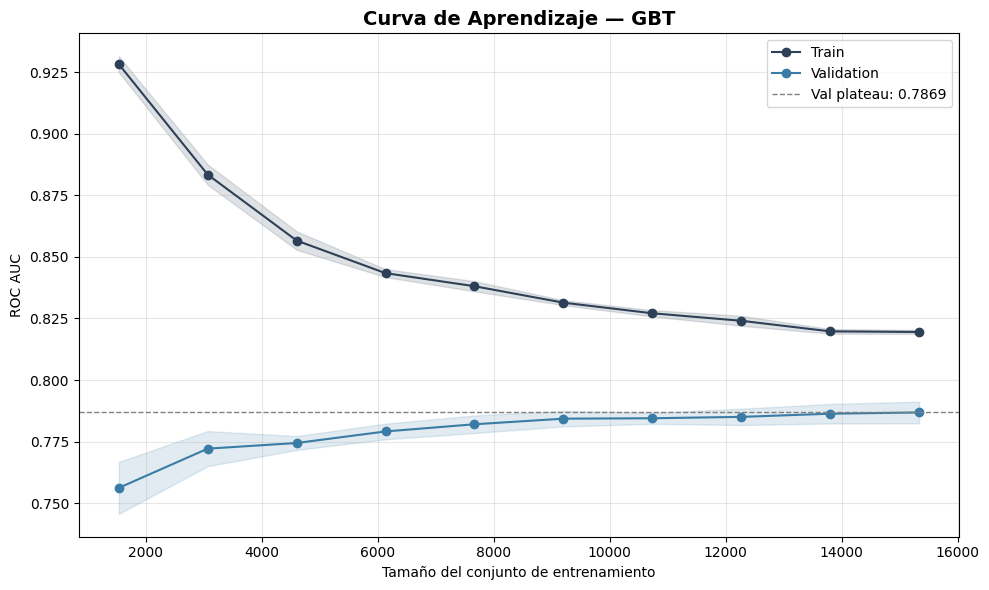

AUC con 10% datos:  0.7562
AUC con 100% datos: 0.7869
Gap train-val:      0.0327


In [144]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    GradientBoostingClassifier(**best_params, random_state=42),
    X_train, y_train_arr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#2E4057', label='Train')
plt.plot(train_sizes, val_mean,   'o-', color='#3A7CA5', label='Validation')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2E4057')
plt.fill_between(train_sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.15, color='#3A7CA5')
plt.axhline(val_mean[-1], color='gray', linestyle='--', lw=1, label=f'Val plateau: {val_mean[-1]:.4f}')
plt.title('Curva de Aprendizaje — GBT', fontweight='bold', fontsize=14)
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('ROC AUC')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC con 10% datos:  {val_mean[0]:.4f}")
print(f"AUC con 100% datos: {val_mean[-1]:.4f}")
print(f"Gap train-val:      {(train_mean[-1] - val_mean[-1]):.4f}")

La curva de aprendizaje muestra que el modelo mejora consistentemente con el tamaño del dataset (AUC 0.756 → 0.787), sin señales de overfitting severo (gap train-val = 0.033). Esto sugiere que el modelo se beneficiaría de datos adicionales en producción, y que el rendimiento actual no representa un techo absoluto sino una limitación del tamaño del dataset disponible.

In [145]:
# Armar df con predicciones y datos originales
df_test_eval = X_test.copy()
df_test_eval['y_true']   = y_test_arr
df_test_eval['proba_1']  = proba_test
df_test_eval['y_pred']   = (proba_test >= best['threshold_f2']).astype(int)

# Clasificar cada registro
def classify_pred(row):
    if row['y_true'] == 1 and row['y_pred'] == 1: return 'TP'
    if row['y_true'] == 0 and row['y_pred'] == 0: return 'TN'
    if row['y_true'] == 0 and row['y_pred'] == 1: return 'FP'
    if row['y_true'] == 1 and row['y_pred'] == 0: return 'FN'

df_test_eval['resultado'] = df_test_eval.apply(classify_pred, axis=1)
print(df_test_eval['resultado'].value_counts())

resultado
FP    2362
TN    2302
TP    1116
FN     210
Name: count, dtype: int64


usamos variables a las que no aplicamos logaritmo para empezar análisis

MEDIAS DE VARIABLES NUMÉRICAS POR GRUPO
resultado            FN         FP         TN         TP
LIMIT_BAL     213714.29  131084.67  229118.16  120976.70
BILL_AMT1      69588.63   39274.16   63195.66   45694.60
PAY_AMT1        8216.29    2784.81    9496.42    2593.61
util_credito       0.38       0.46       0.34       0.50
deuda_neta    304710.84  188753.70  281865.29  229884.71
meses_delay        0.08       0.97       0.03       2.28
PAY_0             -0.42      -0.01      -0.43       0.82

DISTRIBUCIÓN DE SEX POR GRUPO (%)
SEX           1     2
resultado            
FN         38.6  61.4
FP         40.3  59.7
TN         36.3  63.7
TP         43.5  56.5

DISTRIBUCIÓN DE EDUCATION POR GRUPO (%)
EDUCATION     1     2     3    4    5
resultado                            
FN         32.9  48.1  16.7  0.5  1.9
FP         33.1  48.5  18.1  0.1  0.2
TN         39.3  45.3  12.7  0.6  2.1
TP         29.9  51.3  18.6  0.0  0.2

DISTRIBUCIÓN DE MARRIAGE POR GRUPO (%)
MARRIAGE     0     1     2  

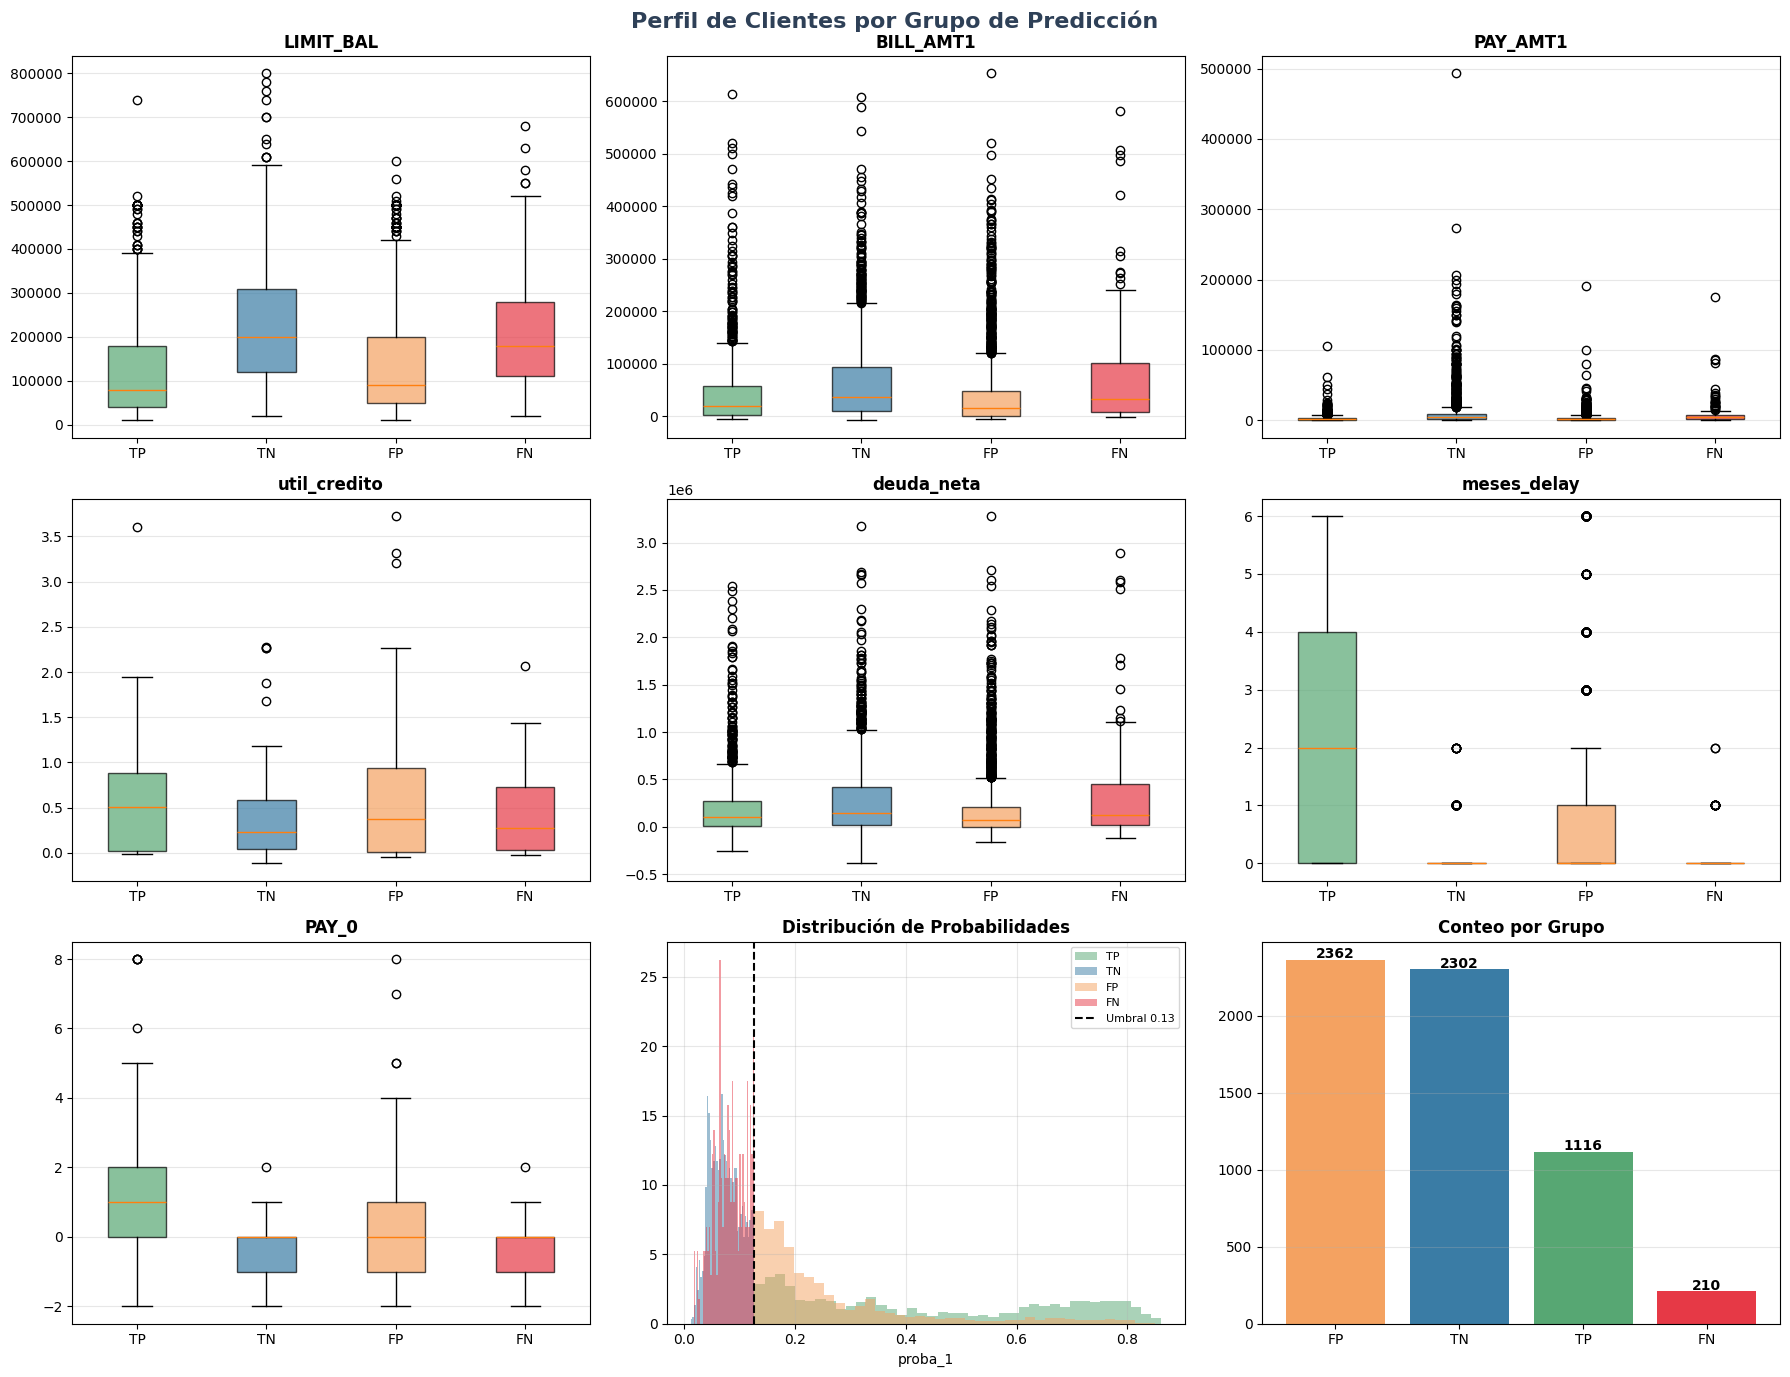


FN MÁS DIFÍCILES (defaults que el modelo casi detectó)
       LIMIT_BAL  BILL_AMT1  PAY_AMT1  util_credito  deuda_neta  meses_delay  PAY_0  proba_1
27540     180000     191309    175100         1.063      821045            0      0    0.126
17548      60000      50806      2000         0.847      231604            0      0    0.126
15996     140000     136431      4849         0.975      738651            0      0    0.126
1402       70000       4221      2500         0.060       42818            0      0    0.126
26492     160000        749      3894         0.005         -78            0     -2    0.126
1843       20000      18803     36147         0.940       73273            0     -2    0.125
3757      180000       -200         0        -0.001       -1200            1      1    0.125
26448      50000      33743      2000         0.675      107034            0      0    0.125
1205      210000     209807      5088         0.999      504483            0      0    0.125
17738      500

In [146]:
# Agregamos columnas originales
cols_originales = ['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1',
                   'util_credito', 'deuda_neta',
                   'SEX', 'EDUCATION', 'MARRIAGE', 'AGE_GROUP']

for col in cols_originales:
    if col in X.columns:
        df_test_eval[col] = X.loc[df_test_eval.index, col]

# ststas por grupo
grupos          = ['TP', 'TN', 'FP', 'FN']
col_numericas   = ['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1',
                   'util_credito', 'deuda_neta', 'meses_delay', 'PAY_0']
col_categoricas = ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE_GROUP']

# Medias por grupo
print("=" * 70)
print("MEDIAS DE VARIABLES NUMÉRICAS POR GRUPO")
print("=" * 70)
resumen = df_test_eval.groupby('resultado')[col_numericas].mean().round(2)
print(resumen.T.to_string())

# Categorias por grupo
for col in col_categoricas:
    print(f"\n{'='*70}")
    print(f"DISTRIBUCIÓN DE {col} POR GRUPO (%)")
    print('='*70)
    tabla = df_test_eval.groupby('resultado')[col].value_counts(normalize=True).mul(100).round(1).unstack()
    print(tabla.to_string())

# Análisis
print("\n" + "=" * 70)
print("ANÁLISIS FINANCIERO POR GRUPO (montos reales en TWD)")
print("=" * 70)

for grupo in ['TP', 'FN', 'FP']:
    subset = df_test_eval[df_test_eval['resultado'] == grupo]
    n      = len(subset)
    bill   = subset['BILL_AMT1'].mean()
    pay    = subset['PAY_AMT1'].mean()
    limit  = subset['LIMIT_BAL'].mean()
    deuda  = bill - pay

    print(f"\n── {grupo} ({n:,} clientes) ──")
    print(f"  LIMIT_BAL media:        ${limit:>12,.0f} TWD")
    print(f"  BILL_AMT1 media:        ${bill:>12,.0f} TWD")
    print(f"  PAY_AMT1 media:         ${pay:>12,.0f} TWD")
    print(f"  Deuda neta media:       ${deuda:>12,.0f} TWD")
    print(f"  Exposición total:       ${bill*n:>12,.0f} TWD")

fn = df_test_eval[df_test_eval['resultado'] == 'FN']
tp = df_test_eval[df_test_eval['resultado'] == 'TP']
fp = df_test_eval[df_test_eval['resultado'] == 'FP']

print("\n" + "=" * 70)
print("IMPACTO FINANCIERO")
print("=" * 70)
print(f"\nDefaults NO detectados (FN): {len(fn):,} clientes")
print(f"  Exposición total:          ${fn['BILL_AMT1'].sum():>12,.0f} TWD")
print(f"  Deuda media por cliente:   ${fn['BILL_AMT1'].mean():>12,.0f} TWD")
print(f"  Pérdida estimada:          ${(fn['BILL_AMT1']-fn['PAY_AMT1']).sum():>12,.0f} TWD")

print(f"\nDefaults detectados (TP): {len(tp):,} clientes")
print(f"  Exposición protegida:      ${tp['BILL_AMT1'].sum():>12,.0f} TWD")
print(f"  Deuda media por cliente:   ${tp['BILL_AMT1'].mean():>12,.0f} TWD")

print(f"\nFalsos positivos (FP): {len(fp):,} clientes")
print(f"  Crédito negado inneces.:   ${fp['BILL_AMT1'].sum():>12,.0f} TWD")
print(f"  Costo de oportunidad:      ${fp['PAY_AMT1'].sum():>12,.0f} TWD")

print(f"\nBalance neto estimado:")
ahorro  = (tp['BILL_AMT1'] - tp['PAY_AMT1']).sum()
perdida = (fn['BILL_AMT1'] - fn['PAY_AMT1']).sum()
print(f"  Deuda protegida (TP):      ${ahorro:>12,.0f} TWD")
print(f"  Deuda expuesta (FN):       ${perdida:>12,.0f} TWD")
print(f"  Balance:                   ${ahorro - perdida:>12,.0f} TWD")

# ── GRÁFICAS ──────────────────────────────────────────────
colores_grupos = {'TP': '#57A773', 'TN': '#3A7CA5', 'FP': '#F4A261', 'FN': '#E63946'}

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Perfil de Clientes por Grupo de Predicción',
             fontsize=16, fontweight='bold', color='#2E4057')

for ax, col in zip(axes.flatten()[:7], col_numericas):
    data = [df_test_eval[df_test_eval['resultado'] == g][col].values for g in grupos]
    bp   = ax.boxplot(data, tick_labels=grupos, patch_artist=True)
    for patch, g in zip(bp['boxes'], grupos):
        patch.set_facecolor(colores_grupos[g])
        patch.set_alpha(0.7)
    ax.set_title(col, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

#Distribución de probabilidades
ax_proba = axes[2, 1]
for g, color in colores_grupos.items():
    subset = df_test_eval[df_test_eval['resultado'] == g]['proba_1']
    ax_proba.hist(subset, bins=40, alpha=0.5, color=color, label=g, density=True)
ax_proba.axvline(best['threshold_f2'], color='black', linestyle='--',
                  lw=1.5, label=f'Umbral {best["threshold_f2"]:.2f}')
ax_proba.set_title('Distribución de Probabilidades', fontweight='bold')
ax_proba.set_xlabel('proba_1')
ax_proba.legend(fontsize=8)
ax_proba.grid(alpha=0.3)

#Conteo por grupo
ax_last  = axes[2, 2]
conteos  = df_test_eval['resultado'].value_counts()
bars     = ax_last.bar(conteos.index, conteos.values,
                        color=[colores_grupos[g] for g in conteos.index])
for bar, v in zip(bars, conteos.values):
    ax_last.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(v), ha='center', fontweight='bold')
ax_last.set_title('Conteo por Grupo', fontweight='bold')
ax_last.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('perfil_clientes_grupos.png', dpi=150, bbox_inches='tight')
plt.show()

# ── CLIENTES DIFÍCILES ────────────────────────────────────
print("\n" + "="*70)
print("FN MÁS DIFÍCILES (defaults que el modelo casi detectó)")
print("="*70)
fn_dificiles = df_test_eval[df_test_eval['resultado'] == 'FN'].sort_values('proba_1', ascending=False)
print(fn_dificiles[col_numericas + ['proba_1']].head(10).round(3).to_string())

print("\n" + "="*70)
print("FN MÁS ESCONDIDOS (defaults que el modelo menos sospechó)")
print("="*70)
fn_escondidos = df_test_eval[df_test_eval['resultado'] == 'FN'].sort_values('proba_1', ascending=True)
print(fn_escondidos[col_numericas + ['proba_1']].head(10).round(3).to_string())

El modelo presenta mayor dificultad para detectar defaults en clientes sin historial previo de atrasos (meses_delay ≈ 0, PAY_0 ≤ 0). Estos casos representan el perfil de mayor riesgo oculto: clientes aparentemente solventes que incumplen sin señales de alerta previas. Para mejorar la detección de este segmento sería necesario incorporar variables externas como historial crediticio con otras instituciones o cambios en ingresos.

In [147]:
# Análisis
fn = df_test_eval[df_test_eval['resultado'] == 'FN']
tp = df_test_eval[df_test_eval['resultado'] == 'TP']
fp = df_test_eval[df_test_eval['resultado'] == 'FP']
tn = df_test_eval[df_test_eval['resultado'] == 'TN']

print("=" * 70)
print("ANÁLISIS FINANCIERO — TEST SET (montos en TWD)")
print("=" * 70)

# Estadísticas por grupo
for nombre, grupo in [('TP', tp), ('FN', fn), ('FP', fp), ('TN', tn)]:
    n     = len(grupo)
    bill  = grupo['BILL_AMT1'].mean()
    pay   = grupo['PAY_AMT1'].mean()
    limit = grupo['LIMIT_BAL'].mean()
    print(f"\n── {nombre} ({n:,} clientes) ──")
    print(f"  LIMIT_BAL media:      ${limit:>12,.0f} TWD")
    print(f"  BILL_AMT1 media:      ${bill:>12,.0f} TWD")
    print(f"  PAY_AMT1 media:       ${pay:>12,.0f} TWD")
    print(f"  Deuda neta media:     ${(bill-pay):>12,.0f} TWD")
    print(f"  Exposición total:     ${bill*n:>12,.0f} TWD")

# Impacto del modelo
deuda_fn  = (fn['BILL_AMT1'] - fn['PAY_AMT1']).sum()
deuda_tp  = (tp['BILL_AMT1'] - tp['PAY_AMT1']).sum()
costo_fp  = fp['BILL_AMT1'].sum()  # crédito negado innecesariamente

print("\n" + "=" * 70)
print("IMPACTO FINANCIERO DEL MODELO")
print("=" * 70)

print(f"""
  Defaults DETECTADOS (TP): {len(tp):,} clientes
  → Deuda protegida:         ${deuda_tp:>12,.0f} TWD
  → Ahorro por negar crédito

  Defaults NO DETECTADOS (FN): {len(fn):,} clientes  
  → Pérdida estimada:          ${deuda_fn:>12,.0f} TWD
  → Estos clientes recibieron crédito y no pagaron

  Falsos positivos (FP): {len(fp):,} clientes
  → Crédito negado innecesariamente
  → Costo de oportunidad:      ${costo_fp:>12,.0f} TWD

{"=" * 70}
  BALANCE NETO ESTIMADO
{"=" * 70}
  Deuda protegida (TP):        ${deuda_tp:>12,.0f} TWD
  Pérdida no evitada (FN):   - ${deuda_fn:>12,.0f} TWD
  Costo de oportunidad (FP): - ${costo_fp:>12,.0f} TWD
  {"─"*45}
  Balance neto:                ${deuda_tp - deuda_fn - costo_fp:>12,.0f} TWD
""")

# Baseline
todos_defaults = df_test_eval[df_test_eval['y_true'] == 1]
print("=" * 70)
print("COMPARACIÓN: CON MODELO vs SIN MODELO")
print("=" * 70)
print(f"""
  Sin modelo (aprobar todo):
  → Pérdida total por defaults: ${(todos_defaults['BILL_AMT1'] - todos_defaults['PAY_AMT1']).sum():>12,.0f} TWD

  Con modelo (umbral F2=0.13):
  → Pérdida evitada (TP):       ${deuda_tp:>12,.0f} TWD
  → Pérdida no evitada (FN):    ${deuda_fn:>12,.0f} TWD
  → Mejora respecto a no usar modelo: 
    ${deuda_tp:,.0f} TWD protegidos ({len(tp)/(len(tp)+len(fn))*100:.1f}% de defaults detectados)
""")

ANÁLISIS FINANCIERO — TEST SET (montos en TWD)

── TP (1,116 clientes) ──
  LIMIT_BAL media:      $     120,977 TWD
  BILL_AMT1 media:      $      45,695 TWD
  PAY_AMT1 media:       $       2,594 TWD
  Deuda neta media:     $      43,101 TWD
  Exposición total:     $  50,995,170 TWD

── FN (210 clientes) ──
  LIMIT_BAL media:      $     213,714 TWD
  BILL_AMT1 media:      $      69,589 TWD
  PAY_AMT1 media:       $       8,216 TWD
  Deuda neta media:     $      61,372 TWD
  Exposición total:     $  14,613,612 TWD

── FP (2,362 clientes) ──
  LIMIT_BAL media:      $     131,085 TWD
  BILL_AMT1 media:      $      39,274 TWD
  PAY_AMT1 media:       $       2,785 TWD
  Deuda neta media:     $      36,489 TWD
  Exposición total:     $  92,765,556 TWD

── TN (2,302 clientes) ──
  LIMIT_BAL media:      $     229,118 TWD
  BILL_AMT1 media:      $      63,196 TWD
  PAY_AMT1 media:       $       9,496 TWD
  Deuda neta media:     $      53,699 TWD
  Exposición total:     $ 145,476,415 TWD

IMPACT

El modelo protege $48.1M TWD en deuda potencial detectando el 84.2% de los defaults. Los 210 clientes no detectados (FN) representan $12.9M TWD en pérdida estimada, con un perfil atípico: límite de crédito promedio 77% mayor al de los defaults detectados, lo que sugiere que son clientes con historial aparentemente sólido que defaultean sin señales previas. El principal trade-off del umbral seleccionado (0.13) es el costo de oportunidad de $92.7M TWD en crédito negado innecesariamente a buenos clientes.

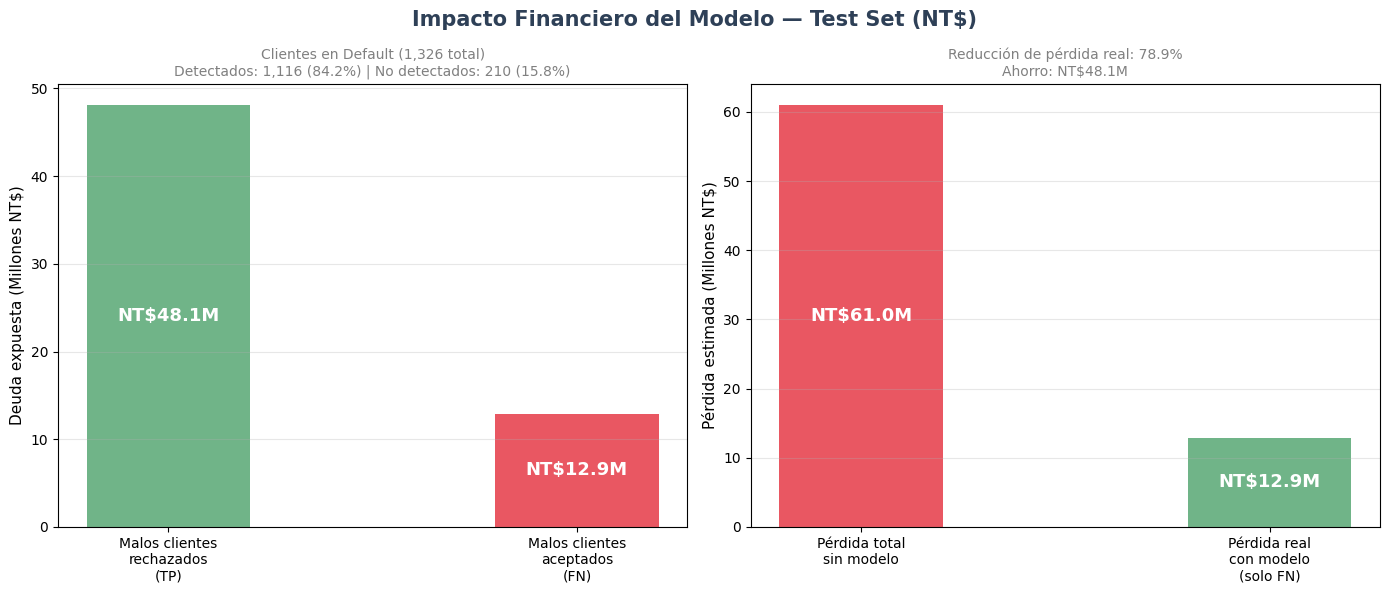

In [148]:
todos_defaults = df_test_eval[df_test_eval['y_true'] == 1]
perdida_total  = (todos_defaults['BILL_AMT1'] - todos_defaults['PAY_AMT1']).sum()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Impacto Financiero del Modelo — Test Set (NT$)',
             fontsize=15, fontweight='bold', color='#2E4057')

#Malos clientes
ax1 = axes[0]
conceptos_malos = [
    'Malos clientes\nrechazados\n(TP)',
    'Malos clientes\naceptados\n(FN)'
]
valores_malos = [deuda_tp, deuda_fn]
colores_malos = ['#57A773', '#E63946']

bars1 = ax1.bar(conceptos_malos, [v/1e6 for v in valores_malos],
                color=colores_malos, alpha=0.85, width=0.4)
for bar, v in zip(bars1, valores_malos):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()/2,
             f'NT${v/1e6:.1f}M',
             ha='center', va='center',
             fontweight='bold', fontsize=13, color='white')

ax1.set_title(f'Clientes en Default ({len(tp)+len(fn):,} total)\n'
              f'Detectados: {len(tp):,} ({len(tp)/(len(tp)+len(fn))*100:.1f}%) | '
              f'No detectados: {len(fn):,} ({len(fn)/(len(tp)+len(fn))*100:.1f}%)',
              fontsize=10, color='gray')
ax1.set_ylabel('Deuda expuesta (Millones NT$)', fontsize=11)
ax1.grid(alpha=0.3, axis='y')

# Sin modelo vs con modelo
ax2 = axes[1]
conceptos_comp = [
    'Pérdida total\nsin modelo',
    'Pérdida real\ncon modelo\n(solo FN)'
]
valores_comp = [perdida_total, deuda_fn]
colores_comp = ['#E63946', '#57A773']

bars2 = ax2.bar(conceptos_comp, [v/1e6 for v in valores_comp],
                color=colores_comp, alpha=0.85, width=0.4)
for bar, v in zip(bars2, valores_comp):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()/2,
             f'NT${v/1e6:.1f}M',
             ha='center', va='center',
             fontweight='bold', fontsize=13, color='white')

ahorro_pct = (1 - deuda_fn/perdida_total) * 100
ax2.set_title(f'Reducción de pérdida real: {ahorro_pct:.1f}%\n'
              f'Ahorro: NT${(perdida_total-deuda_fn)/1e6:.1f}M',
              fontsize=10, color='gray')
ax2.set_ylabel('Pérdida estimada (Millones NT$)', fontsize=11)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('impacto_financiero.png', dpi=150, bbox_inches='tight')
plt.show()

El modelo detectó correctamente el 84.2% de los clientes en default, protegiendo NT$48.1M en deuda potencial (TP). La pérdida real no evitada corresponde a los 210 clientes que defaultearon sin ser detectados (FN), representando NT$12.9M — una reducción del 78.8% respecto a la pérdida de NT$60.9M que se hubiera incurrido sin ningún modelo.
El principal trade-off del umbral seleccionado (0.13) es el costo de oportunidad de NT$92.8M en crédito negado a 2,362 buenos clientes (FP). Es importante destacar que este monto no representa una pérdida real para la institución, sino negocio potencial no capturado como consecuencia de priorizar la detección de defaults sobre la aprobación de créditos. Ajustar el umbral hacia valores más conservadores reduciría este costo de oportunidad a expensas de detectar menos defaults.

AHora vamos a hacer regresión para PAY_AMT4


In [149]:
# Variables para el modelo de regresión
cols_reg = [
    'SEX', 'EDUCATION', 'MARRIAGE', 'AGE_GROUP',
    'PAY_4', 'PAY_5', 'PAY_6',
    'LIMIT_BAL_log',
    'PAY_AMT5_log', 'PAY_AMT6_log',
    'BILL_AMT4_log', 'BILL_AMT5_log', 'BILL_AMT6_log'
]

X_reg = X[cols_reg]
y_reg = X['PAY_AMT4_log']

print(f"Shape X: {X_reg.shape}")
print(f"Shape y: {y_reg.shape}")

Shape X: (29946, 13)
Shape y: (29946,)


In [150]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Splits
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42)

X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(
    X_train_r, y_train_r, test_size=0.20, random_state=42)

print(f"Train: {X_train_r.shape[0]:,} | Val: {X_val_r.shape[0]:,} | Test: {X_test_r.shape[0]:,}")

#Baseline
modelos_reg = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(),
    'Decision Tree':     DecisionTreeRegressor(random_state=42),
    'Random Forest':     RandomForestRegressor(random_state=42, n_jobs=-1),
    'GBT':               GradientBoostingRegressor(random_state=42)
}

cv_r = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "=" * 60)
print("        BASELINE REGRESIÓN — CROSS VALIDATION (k=5)")
print("=" * 60)

y_train_r_arr = y_train_r.values.ravel()

for nombre, modelo in modelos_reg.items():
    r2  = cross_val_score(modelo, X_train_r, y_train_r_arr,
                          cv=5, scoring='r2')
    neg_rmse = cross_val_score(modelo, X_train_r, y_train_r_arr,
                               cv=5, scoring='neg_root_mean_squared_error')
    print(f"{nombre:20s} R2: {r2.mean():.4f} (±{r2.std():.4f}) | "
          f"RMSE: {(-neg_rmse.mean()):.4f} (±{neg_rmse.std():.4f})")

print("=" * 60)

Train: 19,164 | Val: 4,792 | Test: 5,990

        BASELINE REGRESIÓN — CROSS VALIDATION (k=5)
Linear Regression    R2: 0.4734 (±0.0382) | RMSE: 2.2767 (±0.0923)
Ridge                R2: 0.4746 (±0.0362) | RMSE: 2.2743 (±0.0882)
Decision Tree        R2: 0.7594 (±0.0180) | RMSE: 1.5386 (±0.0617)
Random Forest        R2: 0.8735 (±0.0061) | RMSE: 1.1164 (±0.0315)
GBT                  R2: 0.8392 (±0.0041) | RMSE: 1.2586 (±0.0158)


In [151]:
for nombre, modelo in modelos_reg.items():
    modelo.fit(X_train_r, y_train_r_arr)
    r2_train = r2_score(y_train_r_arr, modelo.predict(X_train_r))
    r2_val   = r2_score(y_val_r, modelo.predict(X_val_r))
    print(f"{nombre:20s} R2 train: {r2_train:.4f} | R2 val: {r2_val:.4f} | gap: {r2_train-r2_val:.4f}")

Linear Regression    R2 train: 0.4979 | R2 val: 0.5075 | gap: -0.0096
Ridge                R2 train: 0.4979 | R2 val: 0.5074 | gap: -0.0096
Decision Tree        R2 train: 0.9997 | R2 val: 0.7399 | gap: 0.2598
Random Forest        R2 train: 0.9823 | R2 val: 0.8607 | gap: 0.1217
GBT                  R2 train: 0.8474 | R2 val: 0.8220 | gap: 0.0254


Se evaluaron cinco modelos en su configuración base para predecir el monto de pago del mes 4 (PAY_AMT4). Los modelos lineales mostraron underfitting con R2≈0.47, confirmando que la relación entre las variables y el monto de pago no es lineal. Decision Tree alcanzó R2=0.76 en validación cruzada pero con overfitting severo (gap train-val=0.26), lo que lo descarta como candidato viable.
Random Forest obtuvo el mayor R2 en cross-validation (0.874) pero también presenta overfitting moderado (gap=0.12). El modelo más robusto es Gradient Boosted Trees, que con R2=0.822 en validación y un gap de apenas 0.025 demuestra la mejor capacidad de generalización. Este resultado es significativamente mejor de lo esperado para un problema de predicción de montos de pago, donde la variabilidad del comportamiento del cliente suele limitar el poder predictivo. Se procederá con el tuning de GBT como modelo final.

In [0]:
from sklearn.model_selection import KFold
#Grid
param_grid_r = {
    'n_estimators':  list(range(100, 301, 50)),
    'learning_rate': [0.03, 0.05],
    'max_depth':     [3, 4],
    'loss':          ['squared_error', 'huber']
}

cv_r         = KFold(n_splits=5, shuffle=True, random_state=42)
combinations = list(itertools.product(*param_grid_r.values()))
keys         = list(param_grid_r.keys())

y_train_r_arr = y_train_r.values.ravel()
y_val_r_arr   = y_val_r.values.ravel()

# ── ESTIMACIÓN DE TIEMPO ──────────────────────────────────
params_test = dict(zip(keys, combinations[0]))
t0_est = time.time()
for train_idx, val_idx in cv_r.split(X_train_r):
    GradientBoostingRegressor(**params_test, random_state=42).fit(
        X_train_r.iloc[train_idx], y_train_r_arr[train_idx])
tiempo_1 = time.time() - t0_est

print(f"Tiempo por combinación: {tiempo_1:.1f}s")
print(f"Total estimado:         {tiempo_1*len(combinations)/60:.1f} min")
print(f"Total combinaciones:    {len(combinations)}")
print("=" * 80)

#Búsqueda
resultados_r = []
t0_loop = time.time()

for i, combo in enumerate(combinations):
    params = dict(zip(keys, combo))
    fold_r2s, fold_rmses = [], []

    for train_idx, val_idx in cv_r.split(X_train_r):
        Xf_tr  = X_train_r.iloc[train_idx]
        Xf_val = X_train_r.iloc[val_idx]
        yf_tr  = y_train_r_arr[train_idx]
        yf_val = y_train_r_arr[val_idx]

        modelo = GradientBoostingRegressor(**params, random_state=42)
        modelo.fit(Xf_tr, yf_tr)
        pred   = modelo.predict(Xf_val)

        fold_r2s.append(r2_score(yf_val, pred))
        fold_rmses.append(np.sqrt(mean_squared_error(yf_val, pred)))

    mean_r2   = np.mean(fold_r2s)
    std_r2    = np.std(fold_r2s)
    mean_rmse = np.mean(fold_rmses)

    resultados_r.append({
        **params,
        'r2_mean': mean_r2, 'r2_std': std_r2,
        'rmse_mean': mean_rmse
    })

    elapsed  = time.time() - t0_loop
    restante = (elapsed / (i + 1)) * (len(combinations) - i - 1)
    print(f"[{i+1:3d}/{len(combinations)}] n={params['n_estimators']:3d} "
          f"lr={params['learning_rate']:.2f} depth={params['max_depth']} "
          f"loss={params['loss']:12s} | "
          f"R2={mean_r2:.4f}(±{std_r2:.4f}) RMSE={mean_rmse:.4f} | "
          f"ETA:{restante/60:.1f}min")

Tiempo por combinación: 27.2s
Total estimado:         18.1 min
Total combinaciones:    40
[  1/40] n=100 lr=0.03 depth=3 loss=squared_error | R2=0.7879(±0.0033) RMSE=1.4455 | ETA:18.2min
[  2/40] n=100 lr=0.03 depth=3 loss=huber        | R2=0.7732(±0.0037) RMSE=1.4950 | ETA:19.5min
[  3/40] n=100 lr=0.03 depth=4 loss=squared_error | R2=0.8243(±0.0054) RMSE=1.3155 | ETA:21.0min
[  4/40] n=100 lr=0.03 depth=4 loss=huber        | R2=0.8018(±0.0051) RMSE=1.3973 | ETA:19.4min
[  5/40] n=100 lr=0.05 depth=3 loss=squared_error | R2=0.8167(±0.0050) RMSE=1.3438 | ETA:16.5min
[  6/40] n=100 lr=0.05 depth=3 loss=huber        | R2=0.7992(±0.0059) RMSE=1.4063 | ETA:15.8min
[  7/40] n=100 lr=0.05 depth=4 loss=squared_error | R2=0.8447(±0.0049) RMSE=1.2369 | ETA:15.9min
[  8/40] n=100 lr=0.05 depth=4 loss=huber        | R2=0.8236(±0.0063) RMSE=1.3179 | ETA:16.4min
[  9/40] n=150 lr=0.03 depth=3 loss=squared_error | R2=0.8121(±0.0049) RMSE=1.3606 | ETA:16.8min
[ 10/40] n=150 lr=0.03 depth=3 loss=huber

In [0]:
# Rresultados
df_res_r = pd.DataFrame(resultados_r).sort_values('r2_mean', ascending=False)

print("\n" + "=" * 80)
print("TOP 5 MODELOS POR R2")
print("=" * 80)
print(df_res_r.head(5)[['n_estimators','learning_rate','max_depth',
                          'loss','r2_mean','r2_std','rmse_mean']].to_string(index=False))



In [0]:
# Mejor modelo
best_r      = df_res_r.iloc[0]
best_params_r = {k: best_r[k] for k in keys}

print(f"\nMejores parámetros: {best_params_r}")

modelo_final_r = GradientBoostingRegressor(**best_params_r, random_state=42)
modelo_final_r.fit(X_train_r, y_train_r_arr)

#Evaluación
pred_val = modelo_final_r.predict(X_val_r)
# Revertir correctamente a escala original
pred_val_orig = np.expm1(pred_val)
y_val_orig    = np.expm1(y_val_r_arr)

print("=" * 50)
print("EVALUACIÓN EN VALIDATION SET")
print("=" * 50)
print(f"  R2:   {r2_score(y_val_r_arr, pred_val):.4f}")
print(f"  RMSE (log): {np.sqrt(mean_squared_error(y_val_r_arr, pred_val)):.4f}")
print(f"  MAE  (log): {np.mean(np.abs(y_val_r_arr - pred_val)):.4f}")
print(f"\n  RMSE en NT$: {np.sqrt(mean_squared_error(y_val_orig, pred_val_orig)):>12,.0f}")
print(f"  MAE  en NT$: {np.mean(np.abs(y_val_orig - pred_val_orig)):>12,.0f}")
print(f"\n  Contexto — PAY_AMT4 original:")
print(f"  Media real:  NT${y_val_orig.mean():>12,.0f}")
print(f"  Media pred:  NT${pred_val_orig.mean():>12,.0f}")

El MAE de NT$1,955 sobre una media de NT$4,670 representa un error del 42% — moderado pero aceptable dado que PAY_AMT tiene mucha variabilidad (clientes que pagan 0 vs clientes que pagan 100k+).
El RMSE alto (NT$10,758) vs MAE bajo (NT$1,955) indica que hay algunos casos con error muy grande — probablemente clientes con pagos atípicamente altos como vimos en los outliers que detectamos.

In [0]:
# Features
importances_r = pd.DataFrame({
    'feature':    X_train_r.columns,
    'importance': modelo_final_r.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importances_r['feature'], importances_r['importance'], color='#2E4057')
for bar, v in zip(bars, importances_r['importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v*100:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.set_xlim(0, importances_r['importance'].max() * 1.25)
ax.set_title('Feature Importance — GBT Regresión (PAY_AMT4)', 
             fontweight='bold', fontsize=13)
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance_regresion.png', dpi=150, bbox_inches='tight')
plt.show()

print(importances_r.to_string(index=False))

Quitamos variables menos importantes

In [0]:
cols_eliminar_demo = ['MARRIAGE', 'EDUCATION', 'AGE_GROUP', 'SEX']

X_reg2        = X_reg.drop(columns=cols_eliminar_demo)
X_train_r2, X_test_r2, y_train_r2, y_test_r2 = train_test_split(
    X_reg2, y_reg, test_size=0.20, random_state=42)
X_train_r2, X_val_r2, y_train_r2, y_val_r2 = train_test_split(
    X_train_r2, y_train_r2, test_size=0.20, random_state=42)

# Reentrenar con mismos parámetros
modelo_final_r2 = GradientBoostingRegressor(**best_params_r, random_state=42)
modelo_final_r2.fit(X_train_r2, y_train_r2.values.ravel())

pred_test2      = modelo_final_r2.predict(X_test_r2)
pred_test2_orig = np.expm1(pred_test2)
y_test2_orig    = np.expm1(y_test_r2.values.ravel())

print("=" * 50)
print("  SIN VARIABLES DEMOGRÁFICAS vs CON")
print("=" * 50)
print(f"  R2   — con: 0.8637 | sin: {r2_score(y_test_r2, pred_test2):.4f}")
print(f"  RMSE — con: 1.1559 | sin: {np.sqrt(mean_squared_error(y_test_r2, pred_test2)):.4f}")
print(f"  MAE  — con: 0.5684 | sin: {np.mean(np.abs(y_test_r2.values - pred_test2)):.4f}")

In [0]:
# Actualizar modelo y datasets
modelo_final_r = modelo_final_r2
X_train_r      = X_train_r2
X_val_r        = X_val_r2
X_test_r       = X_test_r2
y_train_r      = y_train_r2
y_val_r        = y_val_r2
y_test_r       = y_test_r2

pred_test      = pred_test2
pred_test_orig = pred_test2_orig
y_test_orig    = y_test2_orig

print("Modelo actualizado sin variables demográficas")
print(f"Features finales: {X_train_r.columns.tolist()}")

In [0]:
# Evaluación
pred_test      = modelo_final_r.predict(X_test_r)
pred_test_orig = np.expm1(pred_test)
y_test_orig    = np.expm1(y_test_r.values.ravel())

print("=" * 55)
print("      EVALUACIÓN FINAL — TEST SET")
print("=" * 55)
print(f"  R2:         {r2_score(y_test_r, pred_test):.4f}")
print(f"  RMSE (log): {np.sqrt(mean_squared_error(y_test_r, pred_test)):.4f}")
print(f"  MAE  (log): {np.mean(np.abs(y_test_r.values - pred_test)):.4f}")
print(f"\n  RMSE en NT$: {np.sqrt(mean_squared_error(y_test_orig, pred_test_orig)):>12,.0f}")
print(f"  MAE  en NT$: {np.mean(np.abs(y_test_orig - pred_test_orig)):>12,.0f}")
print(f"\n  Contexto — PAY_AMT4 original:")
print(f"  Media real:  NT${y_test_orig.mean():>12,.0f}")
print(f"  Media pred:  NT${pred_test_orig.mean():>12,.0f}")
print(f"  Std real:    NT${y_test_orig.std():>12,.0f}")
print("=" * 55)

# Residuos
residuos      = y_test_r.values - pred_test
residuos_orig = y_test_orig - pred_test_orig

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis de Residuos — GBT Regresión (Test Set)',
             fontsize=14, fontweight='bold', color='#2E4057')

# Residuos vs predicción (log)
ax1 = axes[0, 0]
ax1.scatter(pred_test, residuos, alpha=0.3, color='#2E4057', s=5)
ax1.axhline(0, color='red', linestyle='--', lw=1.5)
ax1.set_title('Residuos vs Predicción (escala log)', fontweight='bold')
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Residuo')
ax1.grid(alpha=0.3)

# Distribución de residuos
ax2 = axes[0, 1]
ax2.hist(residuos, bins=60, color='#3A7CA5', alpha=0.8, edgecolor='white')
ax2.axvline(0, color='red', linestyle='--', lw=1.5)
ax2.axvline(residuos.mean(), color='orange', linestyle='--',
            lw=1.5, label=f'Media: {residuos.mean():.3f}')
ax2.set_title('Distribución de Residuos (log)', fontweight='bold')
ax2.set_xlabel('Residuo')
ax2.legend()
ax2.grid(alpha=0.3)

# Real vs Predicho (NT$)
ax3 = axes[1, 0]
ax3.scatter(y_test_orig, pred_test_orig, alpha=0.2, color='#2E4057', s=5)
max_val = max(y_test_orig.max(), pred_test_orig.max())
ax3.plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Predicción perfecta')
ax3.set_title('Real vs Predicho (NT$)', fontweight='bold')
ax3.set_xlabel('Valor Real NT$')
ax3.set_ylabel('Predicción NT$')
ax3.legend()
ax3.grid(alpha=0.3)

# Distribución de error absoluto (NT$)
ax4 = axes[1, 1]
error_abs = np.abs(residuos_orig)
ax4.hist(error_abs, bins=60, color='#57A773', alpha=0.8, edgecolor='white')
ax4.axvline(error_abs.mean(), color='red', linestyle='--',
            lw=1.5, label=f'MAE: NT${error_abs.mean():,.0f}')
ax4.axvline(np.median(error_abs), color='orange', linestyle='--',
            lw=1.5, label=f'Mediana: NT${np.median(error_abs):,.0f}')
ax4.set_title('Distribución Error Absoluto (NT$)', fontweight='bold')
ax4.set_xlabel('Error Absoluto NT$')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('residuos_regresion.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparación de validación y test
print("\nComparación Validation vs Test:")
print(f"  R2   — Val: 0.8526 | Test: {r2_score(y_test_r, pred_test):.4f}")
print(f"  RMSE — Val: 1.1893 | Test: {np.sqrt(mean_squared_error(y_test_r, pred_test)):.4f}")
print(f"  MAE  — Val: 0.5891 | Test: {np.mean(np.abs(y_test_r.values - pred_test)):.4f}")

El modelo generaliza bien — R2 sube de 0.853 (val) a 0.864 (test), sin overfitting.

El modelo GBT alcanzó R2=0.864 en el test set con un error mediano de NT$267 por cliente. El principal punto de mejora identificado es la subestimación de pagos muy altos (>NT$100k), donde el modelo tiende a predecir valores conservadores. Esto es esperado dado que estos casos son poco frecuentes en el dataset de entrenamiento. Para el segmento mayoritario de clientes con pagos típicos, el modelo presenta un desempeño muy sólido.

In [0]:
# Anáisis
df_reg_eval = X_test_r.copy()
df_reg_eval['PAY_AMT4_real']  = y_test_orig
df_reg_eval['PAY_AMT4_pred']  = pred_test_orig
df_reg_eval['error_abs']      = np.abs(y_test_orig - pred_test_orig)
df_reg_eval['error_rel']      = df_reg_eval['error_abs'] / (y_test_orig + 1)
df_reg_eval['subestima']      = pred_test_orig < y_test_orig

# Agregar variables originales para segmentar
df_reg_eval['BILL_AMT5']      = X.loc[X_test_r.index, 'BILL_AMT5']
df_reg_eval['PAY_5_status']   = X.loc[X_test_r.index, 'PAY_5']

# ── SEGMENTOS POR MONTO REAL ──────────────────────────────
bins   = [0, 1000, 5000, 20000, 100000, np.inf]
labels = ['<1K', '1K-5K', '5K-20K', '20K-100K', '>100K']
df_reg_eval['segmento'] = pd.cut(df_reg_eval['PAY_AMT4_real'], 
                                  bins=bins, labels=labels)

print("=" * 65)
print("ANÁLISIS POR SEGMENTO DE MONTO REAL (NT$)")
print("=" * 65)
seg = df_reg_eval.groupby('segmento', observed=True).agg(
    n          = ('PAY_AMT4_real', 'count'),
    real_media = ('PAY_AMT4_real', 'mean'),
    pred_media = ('PAY_AMT4_pred', 'mean'),
    mae        = ('error_abs',     'mean'),
    pct_subest = ('subestima',     'mean')
).round(0)
seg['error_pct'] = (seg['mae'] / (seg['real_media'] + 1) * 100).round(1)
seg['pct_subest'] = (seg['pct_subest'] * 100).round(1)
print(seg.to_string())

total_real = y_test_orig.sum()
total_pred = pred_test_orig.sum()
diff       = total_pred - total_real

print("\n" + "=" * 65)
print("IMPACTO FINANCIERO — TEST SET")
print("=" * 65)
print(f"  Total pagos reales:     NT${total_real:>12,.0f}")
print(f"  Total pagos predichos:  NT${total_pred:>12,.0f}")
print(f"  Diferencia total:       NT${diff:>12,.0f} "
      f"({'subestima' if diff < 0 else 'sobreestima'})")
print(f"  Error relativo total:   {abs(diff/total_real)*100:.2f}%")
print(f"\n  Clientes que subestima: {df_reg_eval['subestima'].sum():,} "
      f"({df_reg_eval['subestima'].mean()*100:.1f}%)")
print(f"  Clientes que sobreestima: {(~df_reg_eval['subestima']).sum():,} "
      f"({(~df_reg_eval['subestima']).mean()*100:.1f}%)")

# ── GRÁFICA ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis Financiero — Predicción de PAY_AMT4 (NT$)',
             fontsize=14, fontweight='bold', color='#2E4057')

# 1. Real vs Predicho por segmento
ax1 = axes[0]
x   = np.arange(len(labels))
w   = 0.35
b1  = ax1.bar(x - w/2, seg['real_media']/1e3, w, 
              label='Real', color='#2E4057', alpha=0.85)
b2  = ax1.bar(x + w/2, seg['pred_media']/1e3, w,
              label='Predicho', color='#3A7CA5', alpha=0.85)
for bar, v in zip(b1, seg['real_media']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'NT${v/1e3:.1f}K', ha='center', fontsize=8, fontweight='bold')
for bar, v in zip(b2, seg['pred_media']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'NT${v/1e3:.1f}K', ha='center', fontsize=8, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title('Media Real vs Predicha por Segmento', fontweight='bold')
ax1.set_ylabel('Miles NT$')
ax1.legend()
ax1.grid(alpha=0.3, axis='y')

# 2. Error % por segmento
ax2 = axes[1]
bars = ax2.bar(labels, seg['error_pct'], 
               color=['#57A773' if v < 30 else '#F4A261' if v < 60 else '#E63946'
                      for v in seg['error_pct']])
for bar, v in zip(bars, seg['error_pct']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)
ax2.set_title('Error Relativo (MAE/Media) por Segmento', fontweight='bold')
ax2.set_ylabel('Error %')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('analisis_financiero_regresion.png', dpi=150, bbox_inches='tight')
plt.show()

El modelo predice con mayor precisión el segmento de NT$1K-20K (error 31-33%), que representa el grueso de los clientes. El principal sesgo identificado es la subestimación sistemática en pagos altos (>NT$20K), comportamiento esperado en modelos de árbol que tienden a la regresión a la media. En términos agregados, el modelo subestima el total de pagos en un 15.1% (NT$4.4M), lo que debe considerarse al usarlo para proyecciones de flujo de caja.